In [2]:
import pandas as pd 
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import seaborn as sns


#### Setting up each file as a DataFrame and checking that they can be read. 

In [3]:
bech_df = pd.read_csv("../Data/Bechdel_IMDB_Merge0524.csv")
cin_df = pd.read_csv("../Data/cinatomy_movie_profiles.csv")
osc_df = pd.read_csv("../Data/oscars_df.csv")
horror_df = pd.read_csv("../Data/horror_movies.csv")


In [4]:
bech_df.head()

,title,year,imdbid,id,bechdelRating,imdbAverageRating,numVotes,runtimeMinutes,genre1,genre2,genre3
0,Miss Jerry,1894,9.0,9779,0,5.4,212.0,45,Romance,NaN,NaN
1,"Story of the Kelly Gang, The",1906,574.0,1349,1,6.0,903.0,70,Action,Adventure,Biography
2,Cleopatra,1912,2101.0,2003,2,5.1,622.0,100,Drama,History,NaN
3,A Florida Enchantment,1914,3973.0,4457,2,5.8,300.0,63,Comedy,NaN,NaN
4,"Birth of a Nation, The",1915,4972.0,1258,2,6.1,26403.0,195,Drama,History,War


In [5]:
cin_df.head()

,movie_title,pacing_efficiency,originality,family_friendly,plot_quality_rating,plot_quality_reasons_for_liking,plot_quality_reasons_for_disliking,dialogues,end_feeling_emotional_adjective,end_feeling_ending_rating,...,sound_bgm_quality,sound_song_tracks_quality,performance_of_actors,connected,references_contained,cognitive_requirement,technical_knowledge_required,photosensitivity_warnings,animal_harm,trailer_or_spoiler
0,The Shawshank Redemption,4,4,2,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,happy,5,...,5,5,5,5,1,3,1,1,1,1
1,The Godfather,4,5,1,5,"['strong_pacing', 'tight_structure']",[],5,bittersweet,5,...,5,4,5,3,4,4,1,1,4,3
2,The Dark Knight,5,5,1,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,bittersweet,5,...,5,4,5,5,4,4,1,3,1,5
3,The Godfather: Part II,4,5,1,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,bittersweet,5,...,5,4,5,5,5,4,1,1,1,5
4,12 Angry Men,5,5,3,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,energized,5,...,3,1,5,1,1,4,1,1,1,3


In [6]:
osc_df.head()

,Unnamed: 0,Film,Oscar Year,Film Studio/Producer(s),Award,Year of Release,Movie Time,Movie Genre,IMDB Rating,IMDB Votes,...,Tomatometer Status,Tomatometer Rating,Tomatometer Count,Audience Status,Audience Rating,Audience Count,Tomatometer Top Critics Count,Tomatometer Fresh Critics Count,Tomatometer Rotten Critics Count,Film ID
0,0,Wings,1927/28,Famous Players-Lasky,Winner,1927,144,"Drama,Romance,War",7.5,"12,221",...,Certified-Fresh,93.0,46.0,Upright,78.0,3530.0,9.0,43.0,3.0,2becf7d5-a3de-46ab-ae45-abdd6b588067
1,1,7th Heaven,1927/28,Fox,Nominee,1927,110,"Drama,Romance",7.7,"3,439",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19ed3295-a878-4fd2-8e60-5cd7b5f93dad
2,2,The Racket,1927/28,The Caddo Company,Nominee,1928,84,"Crime,Drama,Film-Noir",6.7,"1,257",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3111c2d8-0908-4093-8ff3-99c89f2f2f08
3,3,The Broadway Melody,1928/29,Metro-Goldwyn-Mayer,Winner,1929,100,"Drama,Musical,Romance",5.7,"6,890",...,Rotten,33.0,24.0,Spilled,21.0,1813.0,7.0,8.0,16.0,de063f3f-2d35-4e1c-8636-6eb4c16bd236
4,4,Alibi,1928/29,Feature Productions,Nominee,1929,91,"Action,Crime,Romance",5.8,765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,609887c2-877c-43a4-b88c-e40e31096a98


In [7]:
horror_df.head()

,id,original_title,title,original_language,overview,tagline,release_date,poster_path,popularity,vote_count,vote_average,budget,revenue,runtime,status,adult,backdrop_path,genre_names,collection,collection_name
0,760161,Orphan: First Kill,Orphan: First Kill,en,After escaping from an Estonian psychiatric fa...,There's always been something wrong with Esther.,2022-07-27,/pHkKbIRoCe7zIFvqan9LFSaQAde.jpg,5088.584,902,6.9,0,9572765,99,Released,False,/5GA3vV1aWWHTSDO5eno8V5zDo8r.jpg,"Horror, Thriller",760193.0,Orphan Collection
1,760741,Beast,Beast,en,A recently widowed man and his two teenage dau...,Fight for family.,2022-08-11,/xIGr7UHsKf0URWmyyd5qFMAq4d8.jpg,2172.338,584,7.1,0,56000000,93,Released,False,/2k9tBql5GYH328Krj66tDT9LtFZ.jpg,"Adventure, Drama, Horror",NaN,NaN
2,882598,Smile,Smile,en,"After witnessing a bizarre, traumatic incident...","Once you see it, it’s too late.",2022-09-23,/hiaeZKzwsk4y4atFhmncO5KRxeT.jpg,1863.628,114,6.8,17000000,45000000,115,Released,False,/mVNPfpydornVe4H4UCIk7WevWjf.jpg,"Horror, Mystery, Thriller",NaN,NaN
3,756999,The Black Phone,The Black Phone,en,"Finney Blake, a shy but clever 13-year-old boy...",Never talk to strangers.,2022-06-22,/lr11mCT85T1JanlgjMuhs9nMht4.jpg,1071.398,2736,7.9,18800000,161000000,103,Released,False,/AfvIjhDu9p64jKcmohS4hsPG95Q.jpg,"Horror, Thriller",NaN,NaN
4,772450,Presencias,Presences,es,A man who loses his wife and goes to seclude h...,NaN,2022-09-07,/dgDT3uol3mdvwEg0jt1ble3l9hw.jpg,1020.995,83,7.0,0,0,0,Released,False,/ojfzhdwRemcDt1I6pao6vVLw9AA.jpg,Horror,NaN,NaN


#### Checking each dataset's info, if there are any duplicate rows, and their shape.

In [8]:
bech_df.info()
bech_df.duplicated().value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 9718 entries, 0 to 9717
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              9718 non-null   str    
 1   year               9718 non-null   int64  
 2   imdbid             9718 non-null   float64
 3   id                 9718 non-null   int64  
 4   bechdelRating      9718 non-null   int64  
 5   imdbAverageRating  9718 non-null   float64
 6   numVotes           9718 non-null   float64
 7   runtimeMinutes     9718 non-null   str    
 8   genre1             9718 non-null   str    
 9   genre2             8446 non-null   str    
 10  genre3             5807 non-null   str    
dtypes: float64(3), int64(3), str(5)
memory usage: 835.3 KB


False    9718
Name: count, dtype: int64

In [9]:
cin_df.info()
cin_df.duplicated().value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   movie_title                         1000 non-null   str  
 1   pacing_efficiency                   1000 non-null   int64
 2   originality                         1000 non-null   int64
 3   family_friendly                     1000 non-null   int64
 4   plot_quality_rating                 1000 non-null   int64
 5   plot_quality_reasons_for_liking     1000 non-null   str  
 6   plot_quality_reasons_for_disliking  1000 non-null   str  
 7   dialogues                           1000 non-null   int64
 8   end_feeling_emotional_adjective     1000 non-null   str  
 9   end_feeling_ending_rating           1000 non-null   int64
 10  end_feeling_structural_adjective    1000 non-null   str  
 11  immersive                           1000 non-null   int64
 12  impactful         

False    999
True       1
Name: count, dtype: int64

In [10]:
osc_df.info()
osc_df.duplicated().value_counts()


<class 'pandas.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        571 non-null    int64  
 1   Film                              571 non-null    str    
 2   Oscar Year                        571 non-null    str    
 3   Film Studio/Producer(s)           571 non-null    str    
 4   Award                             571 non-null    str    
 5   Year of Release                   571 non-null    int64  
 6   Movie Time                        571 non-null    int64  
 7   Movie Genre                       571 non-null    str    
 8   IMDB Rating                       571 non-null    float64
 9   IMDB Votes                        571 non-null    str    
 10  Movie Info                        438 non-null    str    
 11  Genres                            439 non-null    str    
 12  Critic Consensus   

False    571
Name: count, dtype: int64

In [11]:
horror_df.info()
horror_df.duplicated().value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 32540 entries, 0 to 32539
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 32540 non-null  int64  
 1   original_title     32540 non-null  str    
 2   title              32540 non-null  str    
 3   original_language  32540 non-null  str    
 4   overview           31254 non-null  str    
 5   tagline            12706 non-null  str    
 6   release_date       32540 non-null  str    
 7   poster_path        28066 non-null  str    
 8   popularity         32540 non-null  float64
 9   vote_count         32540 non-null  int64  
 10  vote_average       32540 non-null  float64
 11  budget             32540 non-null  int64  
 12  revenue            32540 non-null  int64  
 13  runtime            32540 non-null  int64  
 14  status             32540 non-null  str    
 15  adult              32540 non-null  bool   
 16  backdrop_path      13545 non-null

False    32540
Name: count, dtype: int64

In [12]:
print(bech_df.shape)
print(cin_df.shape)
print(osc_df.shape)
print(horror_df.shape)

(9718, 11)
(1000, 27)
(571, 30)
(32540, 20)


Dropping duplicates from cin_df, this is the only dataframe that contained any duplicates.

In [13]:
cin_df.drop_duplicates(keep='first', inplace=True)
cin_df.duplicated().value_counts()

False    999
Name: count, dtype: int64

#### Checking for nulls; then determining if the columns need adjusting or if rows need dropping.

In [14]:
bech_df.isnull().sum()

title                   0
year                    0
imdbid                  0
id                      0
bechdelRating           0
imdbAverageRating       0
numVotes                0
runtimeMinutes          0
genre1                  0
genre2               1272
genre3               3911
dtype: int64

The only nulls in bech_df are from subgenres(columns: genre2, genre3); I'll be normalizing the genre columns later in the wrangling process so there is no need to drop any rows.

In [15]:
cin_df.isnull().sum()

movie_title                           0
pacing_efficiency                     0
originality                           0
family_friendly                       0
plot_quality_rating                   0
plot_quality_reasons_for_liking       0
plot_quality_reasons_for_disliking    0
dialogues                             0
end_feeling_emotional_adjective       0
end_feeling_ending_rating             0
end_feeling_structural_adjective      0
immersive                             0
impactful                             0
overall_feeling                       0
visuals                               0
visual_effects                        0
sound_audio_balance_issue             0
sound_bgm_quality                     0
sound_song_tracks_quality             0
performance_of_actors                 0
connected                             0
references_contained                  0
cognitive_requirement                 0
technical_knowledge_required          0
photosensitivity_warnings             0


In [16]:
osc_df.isnull().sum()

Unnamed: 0                            0
Film                                  0
Oscar Year                            0
Film Studio/Producer(s)               0
Award                                 0
Year of Release                       0
Movie Time                            0
Movie Genre                           0
IMDB Rating                           0
IMDB Votes                            0
Movie Info                          133
Genres                              132
Critic Consensus                    232
Content Rating                      132
Directors                           134
Authors                             134
Actors                              132
Original Release Date               132
Streaming Release Date              133
Production Company                  132
Tomatometer Status                  132
Tomatometer Rating                  132
Tomatometer Count                   132
Audience Status                     135
Audience Rating                     132


Presumably, 132 rows are missing information in the following columns of osc_df:
- movie info*
- genres*
- critic consensus
- content rating
- directors
- authors
- actors
- original release date
- streaming release date
- production company
- ... and all columns involving Rotten Tomatoes

*( ***asterick*** where null in column might be a concern moving forward)*


In [17]:
print("Most Recent Release Date:")
print(osc_df['Original Release Date'].max())
print("Earliest Release Date:")
print(osc_df['Original Release Date'].min())


Most Recent Release Date:
2019-11-06
Earliest Release Date:
1927-08-12


The cause of missing values might be movies from early Oscar years.  
***I'll look more into this in later cleaning and wrangling.***

In [18]:
horror_df.isnull().sum()

id                       0
original_title           0
title                    0
original_language        0
overview              1286
tagline              19834
release_date             0
poster_path           4474
popularity               0
vote_count               0
vote_average             0
budget                   0
revenue                  0
runtime                  0
status                   0
adult                    0
backdrop_path        18995
genre_names              0
collection           30234
collection_name      30234
dtype: int64

Nulls in collection_name are fine as is, they are there to let us know that that particular movie is not part of a larger collection.

Nulls in tagline are also fine, not all movies have a tagline, especially the older movies in this dataframe. 
This column is not particularily important to my analysis at this point, but could be interesting to look at as the project grows. 

Columns to drop(due to nulls or repetition): 
- collection (this is an id number and is unnecessary since we have collection_name)
- adult(none of these movies are pornographic, so all rows have same value)
*** I don't plan to use these columns and they have a significt number of nulls. ***


#### Dropping unnecessary columns

The cin_df is very clean already, so I will not be dropping any columns from this dataset. Some columns might not be used in this project as it is currently planned, but I can see using them in the future if this project is updated in the future. 

From bech_df i'll be dropping the id column only.
  
From osc_df I will be dropping several columns that i do not plan to use for this project:
IMDB Votes, Streaming Release Date, Tomatometer Count, Audience Status, Audience Rating, Audience Count, Tomatometer Top Critics Count, Tomatometer Fresh Critics Count, Tomatometer Rotten Critics Count, Film ID, Unnamed
  
From horror_df I will be dropping poster_path, backdrop_path, adult, and collection columns since I will not be using them in this project and don't foresee using them if this project is updated in the future.  



In [19]:
horror_df.drop(['adult', 'id','collection', 'poster_path','backdrop_path', 'vote_count', 'vote_average'], axis=1, inplace=True)
#check if columns dropped
horror_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32540 entries, 0 to 32539
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   original_title     32540 non-null  str    
 1   title              32540 non-null  str    
 2   original_language  32540 non-null  str    
 3   overview           31254 non-null  str    
 4   tagline            12706 non-null  str    
 5   release_date       32540 non-null  str    
 6   popularity         32540 non-null  float64
 7   budget             32540 non-null  int64  
 8   revenue            32540 non-null  int64  
 9   runtime            32540 non-null  int64  
 10  status             32540 non-null  str    
 11  genre_names        32540 non-null  str    
 12  collection_name    2306 non-null   str    
dtypes: float64(1), int64(3), str(9)
memory usage: 3.2 MB


In [20]:
osc_df.drop(['Unnamed: 0','IMDB Votes', 'Streaming Release Date', 'Actors','Year of Release', 'Tomatometer Count', 'Audience Status', 'Audience Rating', 'Audience Count', 'Tomatometer Top Critics Count', 'Tomatometer Fresh Critics Count', 'Tomatometer Rotten Critics Count', 'Film ID'], axis=1, inplace=True)
#check if columns dropped
osc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Film                     571 non-null    str    
 1   Oscar Year               571 non-null    str    
 2   Film Studio/Producer(s)  571 non-null    str    
 3   Award                    571 non-null    str    
 4   Movie Time               571 non-null    int64  
 5   Movie Genre              571 non-null    str    
 6   IMDB Rating              571 non-null    float64
 7   Movie Info               438 non-null    str    
 8   Genres                   439 non-null    str    
 9   Critic Consensus         339 non-null    str    
 10  Content Rating           439 non-null    str    
 11  Directors                437 non-null    str    
 12  Authors                  437 non-null    str    
 13  Original Release Date    439 non-null    str    
 14  Production Company       439 non-null

In [21]:
bech_df.drop(["id"], axis=1, inplace=True)
#check if column dropped
bech_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9718 entries, 0 to 9717
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              9718 non-null   str    
 1   year               9718 non-null   int64  
 2   imdbid             9718 non-null   float64
 3   bechdelRating      9718 non-null   int64  
 4   imdbAverageRating  9718 non-null   float64
 5   numVotes           9718 non-null   float64
 6   runtimeMinutes     9718 non-null   str    
 7   genre1             9718 non-null   str    
 8   genre2             8446 non-null   str    
 9   genre3             5807 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 759.3 KB


#### Dropping rows  
Dropping rows from horror_df that have nulls in the overview, the number of rows being dropped is a small number in comparison to the dataset as a whole and I don't believe will effect the overall analysis. 




In [22]:
horror_df.dropna(subset=['overview'], inplace=True)
#check if rows dropped
horror_df.isnull().sum()

original_title           0
title                    0
original_language        0
overview                 0
tagline              18579
release_date             0
popularity               0
budget                   0
revenue                  0
runtime                  0
status                   0
genre_names              0
collection_name      28970
dtype: int64

I'll be dropping rows from horror_df where their status is not "Released", this includes films in production and in post production which are not useful for this project.

In [23]:
# drop rows where status not equal to released 

un_released = horror_df[horror_df['status'] != 'Released'].index
horror_df.drop(un_released, inplace=True)

#check rows were droppecd
horror_df['status'].value_counts()


status
Released    31142
Name: count, dtype: int64

As suspected, movies with no Movie Info are earlier movies(before 1958), based of this I believe it'll be fine drop these rows.

In [24]:
no_movieinfo = osc_df[osc_df['Movie Info'].isnull()] 
no_movieinfo['Original Release Date'].max()

'1958-09-20'

Dropping all rows with null in the Movie Info column of osc_df also resolved the nulls in almost every other column (significantly: Genres column).

In [25]:
osc_df.dropna(subset=['Movie Info'], inplace=True)
#check if rows dropped, how other columns were effected as well
osc_df.isnull().sum()

Film                         0
Oscar Year                   0
Film Studio/Producer(s)      0
Award                        0
Movie Time                   0
Movie Genre                  0
IMDB Rating                  0
Movie Info                   0
Genres                       0
Critic Consensus           100
Content Rating               0
Directors                    2
Authors                      2
Original Release Date        0
Production Company           0
Tomatometer Status           0
Tomatometer Rating           0
dtype: int64

### Replace Values

Replacing runtime values of 0 with NaN; after researching several of the movies with 0 runtime I determined that was not accurate. Replacing 0 with NaN will help to avoid skewing the data inaccurately.

In [26]:

horror_df['runtime'] = horror_df['runtime'].replace(0, np.nan)
horror_df['runtime'].isnull().sum()

np.int64(1652)

Similarially, replacing "\\N" with NaN in bech_df runtime column, to normalize the columns across the dataframes. 

In [27]:
bech_df['runtimeMinutes'] = bech_df['runtimeMinutes'].replace("\\N", np.nan)
#when trying to change the datatype of runtimeMinutes column, I was getting a ValueError: invalid literal for int() with base 10: '\N' error.

datatype_issues = bech_df[bech_df['runtimeMinutes'] == "\\N"] 
datatype_issues['runtimeMinutes'].value_counts()


Series([], Name: count, dtype: int64)

#### Fixing Datatypes  
  
Checking the datatypes are appropriate and changing them if needed.  
Changing release date/year of horror_df, bech_df, and osc_df to datetime.  
Early movies in osc_df have Oscar Year format as Year/Year (ex. 1986/87.), I'll be leaving this as a string for now. Most of my analysis with this dataframe will involve whether or not a movie is in the dataframe, or searching for a specific year. 


In [28]:

horror_df['release_date'] = pd.to_datetime(horror_df['release_date'])
bech_df['year'] = pd.to_datetime(bech_df['year'])
osc_df['Original Release Date'] = pd.to_datetime(osc_df['Original Release Date'])



In [29]:
bech_df['runtimeMinutes'] = bech_df['runtimeMinutes'].astype(float)
osc_df['Movie Time'] = osc_df['Movie Time'].astype(float)


In [30]:
horror_df.dtypes

original_title                  str
title                           str
original_language               str
overview                        str
tagline                         str
release_date         datetime64[us]
popularity                  float64
budget                        int64
revenue                       int64
runtime                     float64
status                          str
genre_names                     str
collection_name                 str
dtype: object

In [31]:
bech_df.dtypes

title                           str
year                 datetime64[ns]
imdbid                      float64
bechdelRating                 int64
imdbAverageRating           float64
numVotes                    float64
runtimeMinutes              float64
genre1                          str
genre2                          str
genre3                          str
dtype: object

In [32]:
cin_df.dtypes

movie_title                             str
pacing_efficiency                     int64
originality                           int64
family_friendly                       int64
plot_quality_rating                   int64
plot_quality_reasons_for_liking         str
plot_quality_reasons_for_disliking      str
dialogues                             int64
end_feeling_emotional_adjective         str
end_feeling_ending_rating             int64
end_feeling_structural_adjective        str
immersive                             int64
impactful                             int64
overall_feeling                       int64
visuals                               int64
visual_effects                        int64
sound_audio_balance_issue              bool
sound_bgm_quality                     int64
sound_song_tracks_quality             int64
performance_of_actors                 int64
connected                             int64
references_contained                  int64
cognitive_requirement           

In [33]:
osc_df.dtypes

Film                                  str
Oscar Year                            str
Film Studio/Producer(s)               str
Award                                 str
Movie Time                        float64
Movie Genre                           str
IMDB Rating                       float64
Movie Info                            str
Genres                                str
Critic Consensus                      str
Content Rating                        str
Directors                             str
Authors                               str
Original Release Date      datetime64[us]
Production Company                    str
Tomatometer Status                    str
Tomatometer Rating                float64
dtype: object

#### Rename Columns 
This step will create consistency amongst the dataframes when we start making SQL tables and queries.

In [34]:
horror_df.rename(columns={'popularity': 'tmdb_rating', 'genre_names': 'movie_genres'}, inplace=True)

#checking if column name changed 
horror_df.info()

<class 'pandas.DataFrame'>
Index: 31142 entries, 0 to 32537
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   original_title     31142 non-null  str           
 1   title              31142 non-null  str           
 2   original_language  31142 non-null  str           
 3   overview           31142 non-null  str           
 4   tagline            12628 non-null  str           
 5   release_date       31142 non-null  datetime64[us]
 6   tmdb_rating        31142 non-null  float64       
 7   budget             31142 non-null  int64         
 8   revenue            31142 non-null  int64         
 9   runtime            29490 non-null  float64       
 10  status             31142 non-null  str           
 11  movie_genres       31142 non-null  str           
 12  collection_name    2281 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(8)
memory usage: 3.3 MB


In [35]:
bech_df.rename(columns={
    "year": "release_date",
    "imdbAverageRating": "imdb_rating",
    "bechdelRating": "bechdel_rating",
    "runtimeMinutes": "runtime",
    "numVotes": "imdb_votes"
    }, inplace=True)

#checking if column names changed
bech_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9718 entries, 0 to 9717
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title           9718 non-null   str           
 1   release_date    9718 non-null   datetime64[ns]
 2   imdbid          9718 non-null   float64       
 3   bechdel_rating  9718 non-null   int64         
 4   imdb_rating     9718 non-null   float64       
 5   imdb_votes      9718 non-null   float64       
 6   runtime         9710 non-null   float64       
 7   genre1          9718 non-null   str           
 8   genre2          8446 non-null   str           
 9   genre3          5807 non-null   str           
dtypes: datetime64[ns](1), float64(4), int64(1), str(4)
memory usage: 759.3 KB


In [36]:
cin_df.rename(columns={"movie_title": "title"}, inplace=True)
#checking if column name changed
cin_df.info()

<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   title                               999 non-null    str  
 1   pacing_efficiency                   999 non-null    int64
 2   originality                         999 non-null    int64
 3   family_friendly                     999 non-null    int64
 4   plot_quality_rating                 999 non-null    int64
 5   plot_quality_reasons_for_liking     999 non-null    str  
 6   plot_quality_reasons_for_disliking  999 non-null    str  
 7   dialogues                           999 non-null    int64
 8   end_feeling_emotional_adjective     999 non-null    str  
 9   end_feeling_ending_rating           999 non-null    int64
 10  end_feeling_structural_adjective    999 non-null    str  
 11  immersive                           999 non-null    int64
 12  impactful               

In [37]:
osc_df.rename(columns={
    "Film": "title",
    "Oscar Year": "oscar_year",
    "Film Studio/Producer(s)": "studio_producer",
    "Award": "oscar_award",
    "Movie Time": "runtime",
    "Movie Info": "overview",
    "Genres": "genres",
    "Critic Consensus": "critic_consensus",
    "Content Rating": "content_rating",
    "Directors": "directors",
    "Authors": "authors",
    "Original Release Date": "release_date",
    "Movie Genre": "movie_genre",
    "Production Company": "production_company",
    "Tomatometer Rating": "tomatometer_rating",
    "IMDB Rating": "imdb_rating",
    "Tomatometer Status": "tomatometer_status"}, inplace= True)

osc_df.info()

<class 'pandas.DataFrame'>
Index: 438 entries, 0 to 561
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   title               438 non-null    str           
 1   oscar_year          438 non-null    str           
 2   studio_producer     438 non-null    str           
 3   oscar_award         438 non-null    str           
 4   runtime             438 non-null    float64       
 5   movie_genre         438 non-null    str           
 6   imdb_rating         438 non-null    float64       
 7   overview            438 non-null    str           
 8   genres              438 non-null    str           
 9   critic_consensus    338 non-null    str           
 10  content_rating      438 non-null    str           
 11  directors           436 non-null    str           
 12  authors             436 non-null    str           
 13  release_date        438 non-null    datetime64[us]
 14  production

### Normalizing Genre Columns  
The horror_df's movie_genres column values are a string with commas seperating each genre and subgenres(if any); this is the template for how we'd like our other dataframes.  

Columns to normalize:    
- bech_df: genre1, genre2, genre3  
- osc_df: movie_genre, genres

__AI (chatgpt) used to help create this function.__

In [38]:

def unify_genres(df, genre_columns):
    for col in genre_columns:
        df[col] = df[col].fillna('').astype(str).apply(lambda x: x.split(',') if ',' in x else [x] if x else [])
    df['movie_genres'] = df[genre_columns].apply(
        lambda row: list({g.strip() for col in genre_columns for g in row[col] if g.strip()}),
        axis=1
    )
    df['movie_genres'] = df['movie_genres'].apply(lambda x: ', '.join(x))
    return df


unify_genres(bech_df, ['genre1', 'genre2', 'genre3'])
unify_genres(osc_df, ['movie_genre', 'genres'])

,title,oscar_year,studio_producer,oscar_award,runtime,movie_genre,imdb_rating,overview,genres,critic_consensus,content_rating,directors,authors,release_date,production_company,tomatometer_status,tomatometer_rating,movie_genres
0,Wings,1927/28,Famous Players-Lasky,Winner,144.0,"[Drama, Romance, War]",7.5,"With World War I afoot, David Armstrong (Richa...","[Action & Adventure, Classics]",Subsequent war epics may have borrowed heavily...,PG-13,William Wellman,"Hope Loring, Louis D. Lighton",1927-08-12,Unknown,Certified-Fresh,93.0,"Classics, Romance, Action & Adventure, Drama, War"
3,The Broadway Melody,1928/29,Metro-Goldwyn-Mayer,Winner,100.0,"[Drama, Musical, Romance]",5.7,"Vaudeville sisters ""Hank"" (Bessie Love) and Qu...","[Musical & Performing Arts, Romance]",The Broadway Melody is interesting as an examp...,NR,Harry Beaumont,"James Gleason, Norman Houston, Sarah Y. Mason",1929-02-01,MGM Home Entertainment,Rotten,33.0,"Musical & Performing Arts, Drama, Musical, Rom..."
6,In Old Arizona,1928/29,Fox,Nominee,95.0,[Western],5.6,"In this early Western, notorious bandit the Ci...","[Action & Adventure, Classics, Western, Rom...",NaN,NR,"Irving Cummings, Raoul Walsh",Tom Barry,1928-12-25,20th Century Fox Film Corporation,Rotten,56.0,"Action & Adventure, Classics, Romance, Western"
9,The Big House,1929/30,Cosmopolitan,Nominee,87.0,"[Crime, Drama, Thriller]",7.1,"After being convicted of manslaughter, drunk d...","[Classics, Drama]",NaN,NR,George W. Hill,"Frances Marion, Martin Flavin, Joseph Farnham,...",1930-05-14,Warner Bros.,Fresh,75.0,"Thriller, Drama, Classics, Crime"
13,Cimarron,1930/31,RKO Radio,Winner,123.0,"[Drama, Western]",5.9,"In 1889, adventurous lawyer and newspaper edit...","[Classics, Drama, Western]",Cimarron is supported by a strong performance ...,NR,Wesley Ruggles,"Howard Estabrook, Edna Ferber",1931-01-26,MGM Home Entertainment,Rotten,50.0,"Drama, Classics, Western"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,A Star Is Born,2018,"Bill Gerber, Bradley Cooper, and Lynette Howel...",Nominee,136.0,"[Drama, Music, Romance]",7.6,Seasoned musician Jackson Maine discovers -- a...,[Drama],"With appealing leads, deft direction, and an a...",R,Bradley Cooper,"Will Fetters, Eric Roth, Bradley Cooper",2018-10-05,Warner Bros. Pictures,Certified-Fresh,90.0,"Drama, Music, Romance"
553,Vice,2018,"Dede Gardner, Jeremy Kleiner, Adam McKay, and ...",Nominee,132.0,"[Biography, Comdey, Drama]",7.2,Gov. George W. Bush of Texas picks Dick Cheney...,[Drama],"Vice takes scattershot aim at its targets, but...",R,Adam McKay,Adam McKay,2018-12-25,Annapurna Pictures,Fresh,65.0,"Drama, Comdey, Biography"
557,The Irishman,2019,"Martin Scorsese, Robert De Niro, Jane Rosentha...",Nominee,209.0,"[Biography, Crime, Drama]",7.8,"In the 1950s, truck driver Frank Sheeran gets ...","[Drama, Mystery & Suspense]",An epic gangster drama that earns its extended...,R,Martin Scorsese,Steven Zaillian,2019-11-01,Netflix,Certified-Fresh,96.0,"Mystery & Suspense, Drama, Crime, Biography"
559,Joker,2019,"Todd Phillips, Bradley Cooper, and Emma Tillin...",Nominee,122.0,"[Crime, Drama, Thriller]",8.4,"Forever alone in a crowd, failed comedian Arth...","[Action & Adventure, Drama, Mystery & Suspense]",Joker gives its infamous central character a c...,R,Todd Phillips,"Todd Phillips, Scott Silver",2019-10-04,Warner Bros. Pictures,Fresh,68.0,"Thriller, Crime, Action & Adventure, Drama, My..."


Dropping the columns that have been unified.

In [39]:
osc_df.drop(['movie_genre', 'genres'], axis=1, inplace=True)
bech_df.drop(['genre1', 'genre2', 'genre3'], axis=1, inplace=True)

Changing the oscar_award column due to issues later in analysis with duplicate titles because of this column. 


In [40]:
#checking counts of each occurence
osc_df['oscar_award'].value_counts()

oscar_award
Nominee    356
Winner      82
Name: count, dtype: int64

In [41]:
# get the counts of each occurence(nominee or winner)
counts = osc_df.groupby(['title', 'oscar_award']).size().reset_index(name='award_count')
counts_df = counts.pivot(index='title', columns='oscar_award', values='award_count').fillna(0).astype(int)

#merge back into original df

osc_df = pd.merge(counts_df, osc_df, on='title', how='left')

#rename columns to osc_nomination and osc_win for consistency 
#drop oscar_award column (no longer needed)
osc_df.rename(columns={'Nominee': 'osc_nomination', 'Winner': 'osc_win'}, inplace=True)
osc_df.drop(['oscar_award'], axis=1, inplace=True)

#check 
osc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   title               438 non-null    str           
 1   osc_nomination      438 non-null    int64         
 2   osc_win             438 non-null    int64         
 3   oscar_year          438 non-null    str           
 4   studio_producer     438 non-null    str           
 5   runtime             438 non-null    float64       
 6   imdb_rating         438 non-null    float64       
 7   overview            438 non-null    str           
 8   critic_consensus    338 non-null    str           
 9   content_rating      438 non-null    str           
 10  directors           436 non-null    str           
 11  authors             436 non-null    str           
 12  release_date        438 non-null    datetime64[us]
 13  production_company  438 non-null    str           
 14  tomat

#### Creating New DataFrames  
These new dataframes will be converted into tables in our database for SQL queries.  
Tables: 
- movies
- ratings
- financials
- cinatomy
- affiliates


In [42]:
df1= horror_df[['title', 'original_title', 'original_language', 'overview', 'tagline', 'collection_name', 'runtime', 'release_date', 'movie_genres']]
df2= osc_df[['title', 'overview', 'runtime', 'release_date', 'movie_genres']]
df3= bech_df[['title','runtime', 'release_date', 'movie_genres']]
df4= cin_df[['title']]


cin_mer = pd.merge(df4, df1, on='title', how= 'outer')
osbe_mer = pd.merge(df2, df3, on='title', how='left')
movies_df = pd.merge(cin_mer, osbe_mer, on= 'title', how= 'outer')


movies_df.drop_duplicates(subset=['title', 'release_date'], keep='first')

#merging these dataframes has created new columns, with x or y suffixes
#combine _x and _y columns into one column, keeping the non-null values from either column

movies_df['overview'] = movies_df['overview_x'].combine_first(movies_df['overview_y'])
movies_df.drop(['overview_x', 'overview_y'], axis=1, inplace=True)

movies_df['runtime'] = movies_df['runtime_x'].combine_first(movies_df['runtime_y'])
movies_df.drop(['runtime_x', 'runtime_y'], axis=1, inplace=True)

movies_df['release_date'] = movies_df['release_date_x'].combine_first(movies_df['release_date_y'])
movies_df.drop(['release_date_x', 'release_date_y'], axis=1, inplace=True)

movies_df['movie_genres'] = movies_df['movie_genres'].combine_first(movies_df['movie_genres_x'])
movies_df['movie_genres'] = movies_df['movie_genres'].combine_first(movies_df['movie_genres_y'])
movies_df.drop(['movie_genres_x', 'movie_genres_y'], axis=1, inplace=True)


movies_df.drop_duplicates(subset=['title'], inplace=True)

movies_df.insert(0, 'movie_id', range(1, len(movies_df) + 1))
movies_df.info()


# checking all movie_id values are unique 
print(movies_df['movie_id'].nunique())
print(movies_df['title'].nunique())



<class 'pandas.DataFrame'>
Index: 29442 entries, 0 to 32331
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   movie_id           29442 non-null  int64         
 1   title              29442 non-null  str           
 2   original_title     28282 non-null  str           
 3   original_language  28282 non-null  str           
 4   tagline            11560 non-null  str           
 5   collection_name    2217 non-null   str           
 6   runtime            434 non-null    float64       
 7   release_date       434 non-null    datetime64[ns]
 8   movie_genres       28693 non-null  str           
 9   overview           28693 non-null  str           
dtypes: datetime64[ns](1), float64(1), int64(1), str(7)
memory usage: 2.5 MB
29442
29442


In [43]:
# financials table ---  movie_id, budget, revenue 
df1 = movies_df[['movie_id', 'title']]
df2 = horror_df[['title', 'budget', 'revenue']]

fin_info = pd.merge(df1, df2, on="title", how= 'right')
financials_df = fin_info.drop_duplicates().reset_index(drop=True)

#movie_id column datatype needs to be turned back into an integer
financials_df['movie_id'] = financials_df['movie_id'].astype('Int64')

financials_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 29188 entries, 0 to 29187
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  29188 non-null  Int64
 1   title     29188 non-null  str  
 2   budget    29188 non-null  int64
 3   revenue   29188 non-null  int64
dtypes: Int64(1), int64(2), str(1)
memory usage: 940.8 KB


In [44]:
# ratings table  movie_id, tmdb rating, imdb rating, tomatometer rating, bechdel rating, content rating, oscar award

df1 = movies_df[['movie_id', 'title']]
df2 = horror_df[['title', 'tmdb_rating']]
df3 =osc_df[['title', 'osc_nomination', 'osc_win', 'oscar_year', 'imdb_rating', 'critic_consensus', 'tomatometer_status', 'tomatometer_rating']]
df4 = bech_df[['title', 'bechdel_rating', 'imdb_rating']]


#merge all four dataframes

ratings1 = pd.merge(df2, df3, on='title', how='outer')
ratings2 = pd.merge(ratings1, df4, on= 'title', how= 'outer')
ratings_df = pd.merge(df1, ratings2, on= 'title', how= "left")

# combining _x and _y suffix columns into one column and dropping the suffix columns
ratings_df['imdb_rating'] = ratings_df['imdb_rating_x'].combine_first(ratings_df['imdb_rating_y'])
ratings_df.drop(['imdb_rating_x', 'imdb_rating_y'], axis=1, inplace=True)

#movie_id column datatype needs to be turned back into an integer
ratings_df['movie_id'] = ratings_df['movie_id'].astype('Int64')

ratings_df.info()



<class 'pandas.DataFrame'>
RangeIndex: 32484 entries, 0 to 32483
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            32484 non-null  Int64  
 1   title               32484 non-null  str    
 2   tmdb_rating         31285 non-null  float64
 3   osc_nomination      488 non-null    float64
 4   osc_win             488 non-null    float64
 5   oscar_year          488 non-null    str    
 6   critic_consensus    368 non-null    str    
 7   tomatometer_status  488 non-null    str    
 8   tomatometer_rating  488 non-null    float64
 9   bechdel_rating      2306 non-null   float64
 10  imdb_rating         2506 non-null   float64
dtypes: Int64(1), float64(6), str(4)
memory usage: 2.8 MB


In [45]:
# affiliates table affiliate_id, stuio, director, producer 

df1= movies_df[['movie_id', 'title']]
df2 = osc_df[['title', 'studio_producer', 'directors', 'authors', 'production_company']]

aff_info = pd.merge(df1, df2, on='title', how='right')
affiliates_df = aff_info.drop_duplicates().reset_index(drop=True)

#movie_id column datatype needs to be turned back into an integer
affiliates_df['movie_id'] = affiliates_df['movie_id'].astype('Int64')


affiliates_df.info()



<class 'pandas.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   movie_id            438 non-null    Int64
 1   title               438 non-null    str  
 2   studio_producer     438 non-null    str  
 3   directors           436 non-null    str  
 4   authors             436 non-null    str  
 5   production_company  438 non-null    str  
dtypes: Int64(1), str(5)
memory usage: 21.1 KB


In [46]:
# cinatomy/subjective --- table movie_id, every column i think i'll use except title from cinatomy

df1= movies_df[['movie_id', 'title']]
df2 = cin_df[['title', 'originality', 'immersive', 'impactful', 'connected', 'visuals', 'visual_effects', 'performance_of_actors', 'trailer_or_spoiler', 'plot_quality_rating', 'end_feeling_ending_rating', 'pacing_efficiency' ]]


cin_info = pd.merge(df1, df2, on='title', how='right')
cinatomy_df = cin_info.drop_duplicates().reset_index(drop=True)

#movie_id column datatype needs to be turned back into an integer
cinatomy_df['movie_id'] = cinatomy_df['movie_id'].astype('Int64')


cinatomy_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   movie_id                   999 non-null    Int64
 1   title                      999 non-null    str  
 2   originality                999 non-null    int64
 3   immersive                  999 non-null    int64
 4   impactful                  999 non-null    int64
 5   connected                  999 non-null    int64
 6   visuals                    999 non-null    int64
 7   visual_effects             999 non-null    int64
 8   performance_of_actors      999 non-null    int64
 9   trailer_or_spoiler         999 non-null    int64
 10  plot_quality_rating        999 non-null    int64
 11  end_feeling_ending_rating  999 non-null    int64
 12  pacing_efficiency          999 non-null    int64
dtypes: Int64(1), int64(11), str(1)
memory usage: 102.6 KB


Dropping the "title" column from each dataframe, movie_id will be primary key of each table (this is not ideal, but given the information in each dataset this makes the most sense for my analysis). 


In [47]:
financials_df.drop(["title"], axis=1, inplace=True)
affiliates_df.drop(["title"], axis=1, inplace=True)
ratings_df.drop(["title"], axis=1, inplace=True)
cinatomy_df.drop(["title"], axis=1, inplace=True)


### Turning DataFrames into CSV Files


In [48]:
movies_df.to_csv('../Data/movies.csv')
financials_df.to_csv('../Data/financials.csv')
affiliates_df.to_csv('../Data/affiliates.csv')
ratings_df.to_csv('../Data/ratings.csv')
cinatomy_df.to_csv('../Data/cinatomy.csv')

### Creating a Database and loading my new Dataframes as Tables

In [49]:

connection = sqlite3.connect('../Data/perfect_movie.db')

movies_df.to_sql('movies', connection, if_exists='replace', index=False)
financials_df.to_sql('financials', connection, if_exists='replace', index=False)
affiliates_df.to_sql('affiliates', connection,  if_exists='replace',index=False)
ratings_df.to_sql('ratings', connection, if_exists='replace', index=False)
cinatomy_df.to_sql('cinatomy', connection, if_exists='replace', index=False)


999

In [50]:

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", connection)

,name
0,movies
1,financials
2,affiliates
3,ratings
4,cinatomy



It's not as simple as just looking at the data provided.
You have to take into account that technology, marketing, streaming services, the internet have all grown and continue to grow. These factors have created an envirment where more movies are being made in larger quantities.    
  
  
Our original datasets don't fit into each other perfectly (like product sales for a coffee shop might).  
__KEEP IN MIND__: This data could be easily used to mislead, I will be as transparent as possible about the data and how I am working with it.

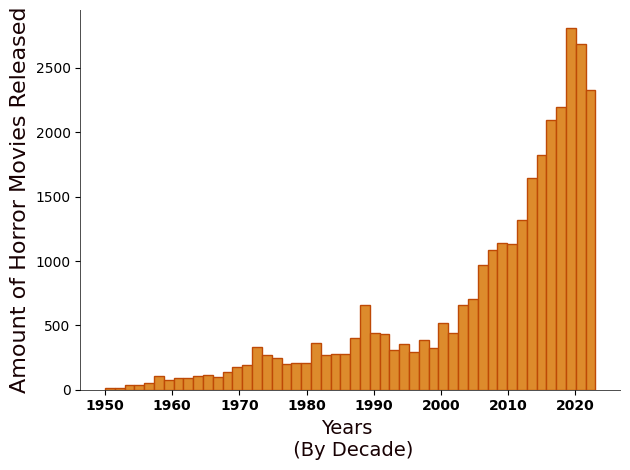

In [51]:
release_data = horror_df['release_date']
plt.hist(release_data, bins=50, color="#DD8B2C", edgecolor="#BE4906")


plt.xlabel('Years \n (By Decade)', fontsize=14, color= "#180103")
plt.ylabel('Amount of Horror Movies Released',fontsize=16,  color= "#180103" )

plt.xticks(fontweight= "bold")
ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
    spine.set_alpha(0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig('../Visualizations/horror_movie_release_freq.png')
plt.show()

Top 10 Horror Movies with the Highest Revenue   
  
__Disclaimer:__ Most of these movies will be newer movies due to inflation, the break-up of the vertically integrated Hollywood studio system after the United States vs. Paramount Pictures in 1948, the rise of drive-ins and art houses after the dismantling of vertical integration, and the ease of restrictions on the exhibition business in the 1980s. 


[vertical integration]: https://www.history.com/articles/hollywood-studio-system-antitrust-monopolies

[restriction ease]: https://www.cobbles.com/simpp_archive/studio-theaters_today.htm
  
    

Additional Links:  
[More Info on the vertically inegrated Hollywood studio system][vertical integration]  
[More Info on the ease of restrictions on the exhibition business in the 1980's][restriction ease]  

There are many factors as to why looking at the highest revenue movies isn't the best way to find out how to make the perfect horror movie, but it can give us insight into which movies are worth analyzing and comparing. 

C:\Users\jessi\AppData\Local\Temp\ipykernel_6600\541276881.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(custom_labels, color = "#122903", fontsize=10, fontweight="bold", rotation=30, ha="right")


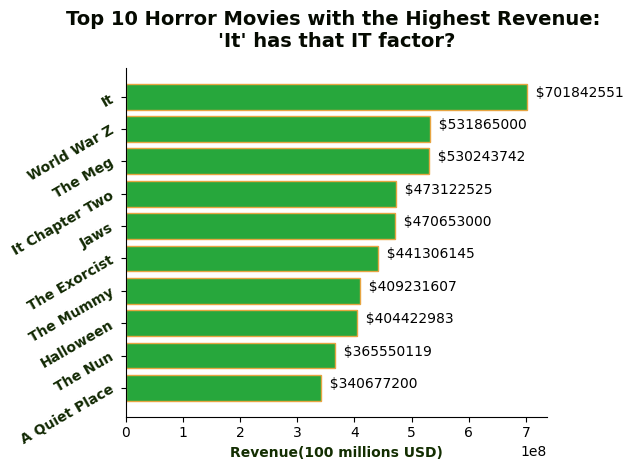

In [52]:
category = "title"
values = "revenue"
movie_rev = horror_df.groupby(category)[values].sum().sort_values(ascending=False)
movie_rev_10 = movie_rev.head(10)



fig, ax = plt.subplots()


ax.barh(movie_rev_10.index, movie_rev_10.values, align='center', edgecolor= "#E7A542", color="#27A73C")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()  
ax.set_xlabel('Revenue(100 millions USD)', color= "#132E01", fontweight= 'bold')
ax.set_title("Top 10 Horror Movies with the Highest Revenue: \n'It' has that IT factor?", color= "#050A01", fontsize=14, fontweight='bold', pad= 15)

custom_labels = movie_rev_10.index
ax.set_yticklabels(custom_labels, color = "#122903", fontsize=10, fontweight="bold", rotation=30, ha="right")


for index, value in enumerate(movie_rev_10.values):
    plt.text(value + 50, index, str(f"  ${movie_rev_10.values[index]}"))

plt.tight_layout()
plt.savefig('../Visualizations/top_horrormovie_rev.png')
plt.show()

Going to go a little broader here, I'm going to take a look at movies that are part of larger collections as opposed to stand alone movies.  

Not every movie(or specifically the creators of the movie) hope to become part of a larger collection, but many would probably like to.  
Logically more movies equates to more revenue. As well as having already built a world to be explored, with societal/paranormal/etc. rules to follow, and characters who are already developed; making less work for creative teams.  

Some movies gain so much popularity the inevietably become part of a collection even though original intent was to be a standalone movie. 
For example, Terrifier(2016) was intended to be a stand alone slasher film based on the character Art the Clown introduced in Damien Leone's short film "The 9th Circle"(2008) and later featured in his anthology "All Hallows Eve"(2013). The original Terrifier has little plot other than indiscriminate murder and gore, the movie intending to showcase the horror of an unstoppable demonic presence with practical effects. The lore of Art the Clown and the plot of the Terrifier franchise grew because of audiences adoration of the character.  
  

[Terrifier]:https://www.looper.com/1584352/terrifier-franchise-untold-truth/  
For More Inormation:
[The Untold Truth of the Terrifier Franchise][Terrifier]


C:\Users\jessi\AppData\Local\Temp\ipykernel_6600\3551843418.py:34: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend = ax.legend(


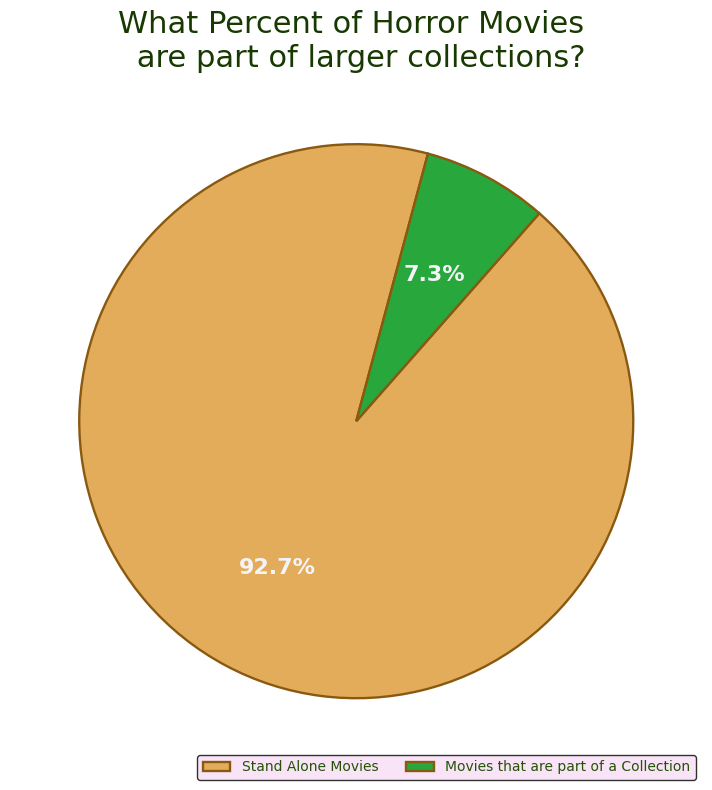

In [53]:
standalone = horror_df['collection_name'].isna().sum()
incollection = horror_df['collection_name'].count()
pie_data = [standalone, incollection]
pie_series = pd.Series(pie_data)


fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotext = ax.pie(
    pie_series,
    labels=None,
    startangle= 75,
    colors=["#E2AC5B", "#27A73C"],
    autopct= "%1.1f%%",
    wedgeprops={
        'edgecolor': "#8A5910", 
        'linewidth': 1.7,     
        'antialiased': True}
    )

ax.set_title(
    "What Percent of Horror Movies \n are part of larger collections?",
    fontsize= 22,
    color= "#183A02",
    loc="center"
    )

for autotext in autotext:
    autotext.set_fontsize(16)
    autotext.set_color("#f4f4f8")
    autotext.set_weight("bold")


legend = ax.legend(
    wedges,
    pie_series.index,
    labels= ["Stand Alone Movies","Movies that are part of a Collection"],
    loc="center right",
    bbox_to_anchor = (1, 0),
    ncol= 2,
    frameon=True,                     
    facecolor="#F8DEF5",           
    edgecolor='black'   
)
for text in legend.get_texts():
    text.set_color("#235205")



plt.tight_layout()

plt.savefig('../Visualizations/collectionvsstanalone.png')
plt.show()


A quick look at the 25 horror movies with the high revenue that are also a part of a larger collection. Among this list of movies, many of these titles coincide with titles from the top 10 highest revenue horror movies.   
This is a significant insight, either there is value in being an addition to a collection(marketing, exposure, name recognition) or movies (or their characters) that are compelling tend to lead to movie collections. 
  
The movies table does contain movies that are not horror genre; but looking back at the original datasets, only movies from the horror_df have a value other than NaN in the collection_name so all the movies listed below are from the horror genre. 

In [54]:
coll_query = """ 
SELECT DISTINCT movies.title, movies.overview, movies.collection_name, financials.revenue
FROM movies
JOIN financials on financials.movie_id = movies.movie_id
WHERE movies.collection_name != "NaN" AND financials.revenue != 0
ORDER BY financials.revenue DESC
LIMIT 25;
"""
pd.read_sql(coll_query, connection)

,title,overview,collection_name,revenue
0,It,"In a small town in Maine, seven children known...",It Collection,701842551
1,The Meg,A deep sea submersible pilot revisits his past...,The Meg Collection,530243742
2,It Chapter Two,27 years after overcoming the malevolent super...,It Collection,473122525
3,Jaws,When an insatiable great white shark terrorize...,Jaws Collection,470653000
4,The Exorcist,12-year-old Regan MacNeil begins to adapt an e...,The Exorcist Collection,441306145
5,The Nun,When a young nun at a cloistered abbey in Roma...,The Nun Collection,365550119
6,A Quiet Place,A family is forced to live in silence while hi...,A Quiet Place Collection,340677200
7,The Conjuring 2,Lorraine and Ed Warren travel to north London ...,The Conjuring Collection,320392818
8,The Conjuring,Paranormal investigators Ed and Lorraine Warre...,The Conjuring Collection,319494638
9,Resident Evil: The Final Chapter,Picking up immediately after the events in Res...,Resident Evil Collection,312242626


I'll take a deeper look at the osc_df further along in my analysis.  
  
For now, I just want to see which movies from our table above were nominated or won Best Picture at the Oscars.
In the query below, I am checking for oscar_year that is not "NaN"(I could also check osc_nomination .and osc_win column where the value is greater or equal to 1), if a movie has never been nominated or won it will not have a value other than NaN.  

If we can make a perfect horror movie, or if it already exists... would it win Best Picture at the Oscars, or do horror movies really get snubbed at Oscars (as rumor suggests)?

In [55]:
coll2_query = """ 
SELECT DISTINCT movies.title, movies.overview
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE ratings.oscar_year != "NaN"
AND movies.title in (SELECT DISTINCT movies.title FROM movies JOIN financials on financials.movie_id = movies.movie_id WHERE movies.collection_name != "NaN" AND financials.revenue != 0 ORDER BY financials.revenue DESC LIMIT 25)
;
"""
pd.read_sql(coll2_query, connection)

,title,overview
0,Jaws,When an insatiable great white shark terrorize...
1,The Exorcist,12-year-old Regan MacNeil begins to adapt an e...



#### Looking at Horror Movie Collections:
  
Does having a higher budget solidify having a better movie?  
Does having a higher budget even guarantee a higher revenue? 


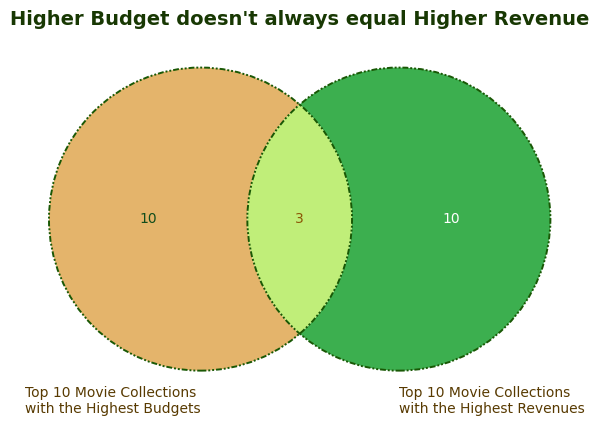

Top 10 horror movie collections with highest revenues:
collection_name
Resident Evil Collection          1233421727
It Collection                     1174965076
Saw Collection                     977089863
Paranormal Activity Collection     886011827
The Conjuring Collection           840887456
Jaws Collection                    798405075
Annabelle Collection               794816136
Scream Collection                  744475660
Final Destination Collection       666766477
Halloween Collection               652766751
Name: revenue, dtype: int64
Top 10 horror movies collections with highest budgets:
collection_name
Resident Evil Collection          288000000
Blade Collection                  164000000
Final Destination Collection      161000000
Van Helsing Collection            160000000
The Meg Collection                150000000
The Exorcist Collection           144300000
Scream Collection                 142000000
Alien Collection                  131000000
The Hannibal Lecter Collecti

In [56]:
# this block of code is to get the insights I will put into the Venn diagram
movie_collection_revenue = horror_df.groupby('collection_name')['revenue'].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False).head(10)
movie_coll_rev = pd.Series(movie_coll_rev) 


movie_collection_budget = horror_df.groupby('collection_name')['budget'].sum()
movie_coll_budget = movie_collection_budget.sort_values(ascending=False).head(10)
movie_coll_budget = pd.Series(movie_coll_budget) 

# get the movies where both lists intersect
lside = movie_coll_budget.index
rside = movie_coll_rev.index
middle = set(lside).intersection(set(rside))


venn = venn2(subsets = (10, 10, 3),
    set_labels = ('Top 10 Movie Collections \nwith the Highest Budgets', 'Top 10 Movie Collections \nwith the Highest Revenues'), 
    set_colors=("#E2AC5B", "#27A73C"),
    alpha= 0.9)

venn2_circles(subsets=(10,10,3),
            color= "#195805",
            linestyle= (0, (3, 1, 1, 1, 1, 1)),
            linewidth= 1.4) 

venn.set_labels[0].set_fontsize(10)
venn.set_labels[1].set_fontsize(10)
venn.set_labels[0].set_color("#583a01")
venn.set_labels[1].set_color("#583a01")

if venn.get_label_by_id('10'):  # leftside
    venn.get_label_by_id('10').set_color( "#114D1B")

if venn.get_label_by_id('01'):  # rigthside
    venn.get_label_by_id('01').set_color('white')

if venn.get_label_by_id('11'):  # intersection
    venn.get_label_by_id('11').set_color("#8B5605")


plt.title("Higher Budget doesn't always equal Higher Revenue",
        color= "#183803",
        fontsize=14,
        fontweight="bold",
        pad= 5)

plt.tight_layout()
plt.savefig('../Visualizations/collrev_bud_Venn.png')
plt.show()




print("Top 10 horror movie collections with highest revenues:")
print(movie_coll_rev)
print("Top 10 horror movies collections with highest budgets:")
print(movie_coll_budget)
print("Horror movie collections that are in both lists: (top 10 highest revenue & top ten highest budget for horror movie collections)")
print(middle)

#### A closer look at what the above Venn diagram shows:

C:\Users\jessi\AppData\Local\Temp\ipykernel_6600\621603342.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, color = "#234603", fontsize=10, fontweight="bold", rotation=30, ha="right")


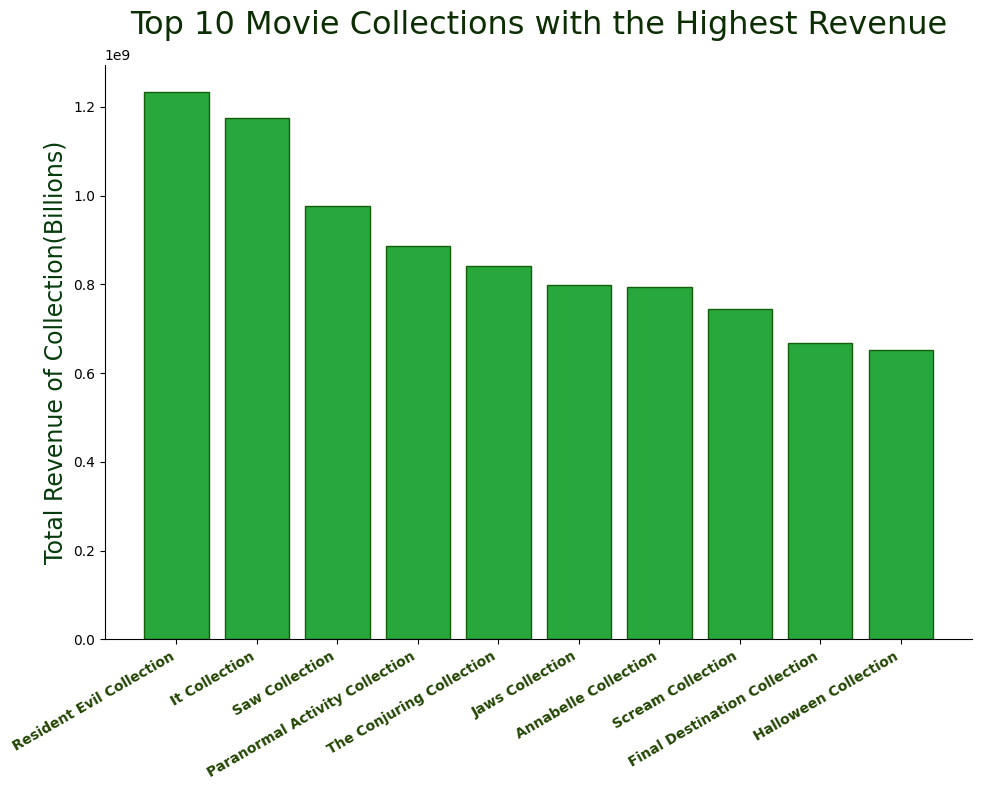

In [57]:
category = "collection_name"
values = "revenue"
movie_collection_revenue = horror_df.groupby(category)[values].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False) 

collection_rev_10 = movie_coll_rev.head(10)

plt.figure(figsize=(10,8))
plt.bar(collection_rev_10.index, collection_rev_10.values, color= "#27A73C", edgecolor= "#145f0a")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Top 10 Movie Collections with the Highest Revenue",
          fontsize= 23,
          color= "#0B2E02",
          pad= 22,
          loc="center")

plt.ylabel("Total Revenue of Collection(Billions)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

custom_labels = collection_rev_10.index
ax.set_xticklabels(custom_labels, color = "#234603", fontsize=10, fontweight="bold", rotation=30, ha="right")

plt.tight_layout()
plt.savefig('../Visualizations/top_movie_collection_rev.png')
plt.show()

C:\Users\jessi\AppData\Local\Temp\ipykernel_6600\3018682940.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, color = "#234603",  fontsize=10, fontweight="bold", rotation=30, ha="right")


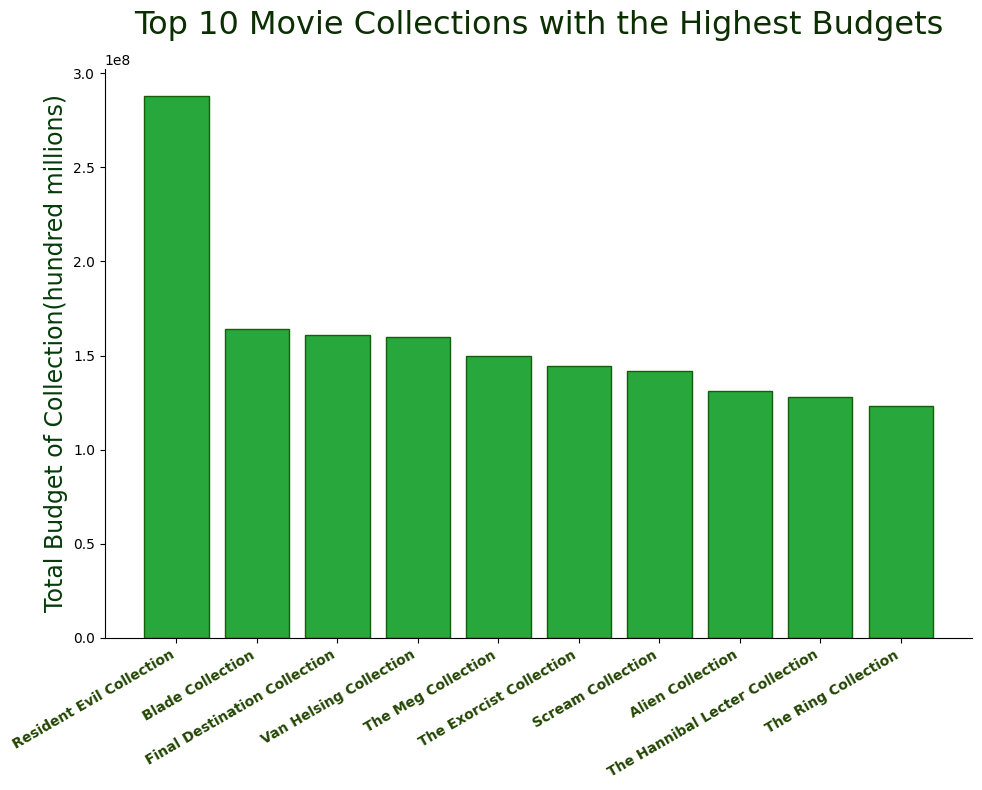

In [58]:
category = "collection_name"
values = "budget"
movie_collection_budget = horror_df.groupby(category)[values].sum()
movie_coll_budget = movie_collection_budget.sort_values(ascending=False) 

collection_budget_10 = movie_coll_budget.head(10)



plt.figure(figsize=(10,8))
plt.bar(collection_budget_10.index, collection_budget_10.values, color= "#27A73C", edgecolor= "#145f0a")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Top 10 Movie Collections with the Highest Budgets",
          fontsize= 23,
          color= "#0B2E02",
          pad= 25,
          loc="center")

plt.ylabel("Total Budget of Collection(hundred millions)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

custom_labels = collection_budget_10.index
ax.set_xticklabels(custom_labels, color = "#234603",  fontsize=10, fontweight="bold", rotation=30, ha="right")

plt.tight_layout()
plt.savefig('../Visualizations/top_movie_collection_budget.png')
plt.show()


Instead of Budget let's take a look at popularity, specifically tmdb rating, to see how that differs from highest revenues.  
In theory, the higher the popularity the higher the revenue would be ....   

An explanation of how popularity scores are determined: 
"Popularity is a fairly important metric here on TMDB. It helps us boost search results, adds an incredibly useful sort value for discover, and is also just kind of fun to see items chart up and down. You can think of popularity as being a "lifetime" popularity score that is impacted by the attributes below.  
For Movies:  
- Number of votes for the day 
- Number of views for the day 
- Number of users who marked it as a "favourite" for the day 
- Number of users who added it to their "watchlist" for the day 
- Release date 
- Number of total votes 
- Previous days score"  

The popularity score, tmdb rating, may not be the traditional idea of popularity. It is more so based on user interaction on TMDB (keep in mind the user demographics also play a role in the scoring). 


In [59]:
def top10rating(df, category, rating):
    movie_collection_pop = df.groupby(category)[rating].sum()
    movie_coll_pop = movie_collection_pop.sort_values(ascending=False) 
    collection_pop_10 = movie_coll_pop.head(10)
    return collection_pop_10

# collection name is category, rating is values we want to look at
# could use other ratings as well, ex. imdb_rating, tomatometer_rating

top10rating(horror_df, "collection_name", "tmdb_rating")

collection_name
Orphan Collection                     5354.442
Jeepers Creepers Collection           1432.840
Halloween Collection                  1209.051
Child's Play Collection                737.393
Wrong Turn Collection                  650.419
X Collection                           581.853
Jack in the Box Collection             578.835
The Conjuring Collection               556.837
Texas Chainsaw Massacre Collection     541.759
The Purge Collection                   540.793
Name: tmdb_rating, dtype: float64

C:\Users\jessi\AppData\Local\Temp\ipykernel_6600\2692377397.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, color = "#234603", fontsize=10, fontweight="bold", rotation=30, ha="right")


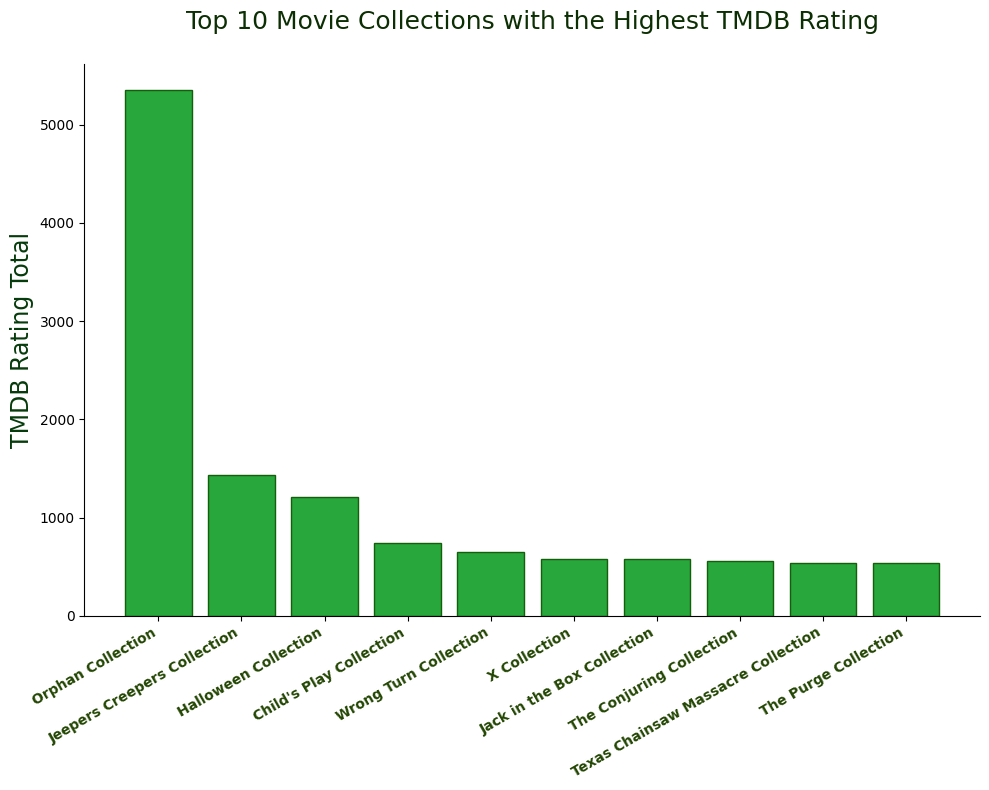

In [60]:

movie_collection_pop = horror_df.groupby("collection_name")["tmdb_rating"].sum()
movie_coll_pop = movie_collection_pop.sort_values(ascending=False) 
collection_pop_10 = movie_coll_pop.head(10)

plt.figure(figsize=(10,8))
plt.bar(collection_pop_10.index, collection_pop_10.values, color= "#27A73C", edgecolor= "#145f0a")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Top 10 Movie Collections with the Highest TMDB Rating",
          fontsize= 18,
          color= "#0B2E02",
          pad= 25,
          loc="center")

plt.ylabel("TMDB Rating Total", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

custom_labels = collection_pop_10.index
ax.set_xticklabels(custom_labels, color = "#234603", fontsize=10, fontweight="bold", rotation=30, ha="right")

plt.tight_layout()
plt.savefig('../Visualizations/top_movie_collection_pop.png')
plt.show()

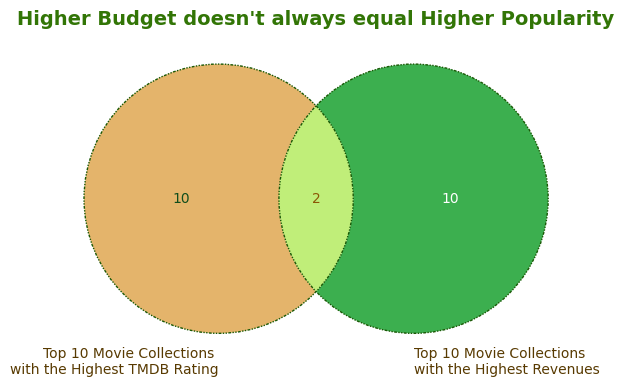

Top 10 horror movie collections with highest revenues:
collection_name
Resident Evil Collection          1233421727
It Collection                     1174965076
Saw Collection                     977089863
Paranormal Activity Collection     886011827
The Conjuring Collection           840887456
Jaws Collection                    798405075
Annabelle Collection               794816136
Scream Collection                  744475660
Final Destination Collection       666766477
Halloween Collection               652766751
Name: revenue, dtype: int64
Top 10 horror movies collections with highest TMDB Rating:
collection_name
Orphan Collection                     5354.442
Jeepers Creepers Collection           1432.840
Halloween Collection                  1209.051
Child's Play Collection                737.393
Wrong Turn Collection                  650.419
X Collection                           581.853
Jack in the Box Collection             578.835
The Conjuring Collection               556.837


In [61]:
# doing the exact same as previous Venn but instead of budget, using popularity(tmdb rating)
movie_collection_revenue = horror_df.groupby('collection_name')['revenue'].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False).head(10)
movie_coll_rev = pd.Series(movie_coll_rev) 

movie_collection_rate = horror_df.groupby('collection_name')['tmdb_rating'].sum()
movie_coll_rate = movie_collection_rate.sort_values(ascending=False).head(10)
movie_coll_rate = pd.Series(movie_coll_rate) 

lside = movie_coll_rate.index
rside = movie_coll_rev.index
middle = set(lside).intersection(set(rside))


venn = venn2(subsets = (10, 10, 2),
    set_labels = ('Top 10 Movie Collections \nwith the Highest TMDB Rating', 'Top 10 Movie Collections \nwith the Highest Revenues'), 
    set_colors=("#E2AC5B", "#27A73C"),
    alpha= 0.9)

venn2_circles(subsets=(10,10,2),
            color= "#195805",
            linestyle= (0, (2, 1, 1, 1, 1, 1)),
            linewidth= 1) 

venn.set_labels[0].set_fontsize(10)
venn.set_labels[1].set_fontsize(10)
venn.set_labels[0].set_color("#583a01")
venn.set_labels[1].set_color("#583a01")

if venn.get_label_by_id('10'):  # leftside
    venn.get_label_by_id('10').set_color( "#114D1B")

if venn.get_label_by_id('01'):  # rigthside
    venn.get_label_by_id('01').set_color('white')

if venn.get_label_by_id('11'):  # intersection
    venn.get_label_by_id('11').set_color("#8B5605")


plt.title("Higher Budget doesn't always equal Higher Popularity",
        color= "#327506",
        fontsize=14,
        fontweight="bold",
        pad= 5)

plt.tight_layout()
plt.savefig('../Visualizations/collrev_rating_Venn.png')
plt.show()



print("Top 10 horror movie collections with highest revenues:")
print(movie_coll_rev)
print("Top 10 horror movies collections with highest TMDB Rating:")
print(movie_coll_rate)
print("Horror movie collections that are in both lists: (top 10 highest revenue & top ten highest tmdb rating for horror movie collections)")
print(middle)


#### Taking a step back from horror movies to look at top-rated films and what they did right...   
  
  
#### Cinatomy Dataset:   
This dataset contains titles of 1,000 well-known films (sourced from IMDb's top-rated titles, 999 after cleaning/wrangling).      

__from IMDB's WEBSITE:__  
"List of top 1000 movies, ranked starting with #1. Rankings are arrived at by combining ratings and percentages from five prominent movie databases: Metacritic, Rotten Tomatoes, IMDb, TCM, and Sight & Sound. Additional points are given to films repeatedly appearing on lists (created by respected critics, film directors, and various publications) of top films.  "
   


It's safe to say Horror Movies are typically not considered 'family friendly', does that automatically knock the genre out of consideration for making a "perfect" movie?  
  
The histogram below shows majority of movies considered in the top 1000 films of all time are family friendly.

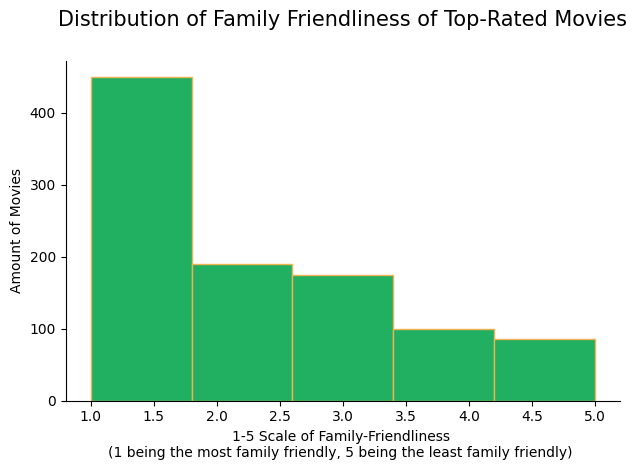

In [62]:
cin_df['family_friendly'].hist(bins=5, color="#21AF61", edgecolor="#F1B254")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('1-5 Scale of Family-Friendliness \n(1 being the most family friendly, 5 being the least family friendly) ')
plt.ylabel('Amount of Movies')
plt.title("Distribution of Family Friendliness of Top-Rated Movies", color= "#030103", pad=25, fontsize=15)


plt.tight_layout()
plt.savefig('../Visualizations/familyfriendly_hist.png')
plt.show()

### Bechdel Score DataFrame

"This dataset covers information about more than 9000 movies such as their titles, genres, ratings on IMDb and scores to the Bechdel test. It is a test invented in 1985 by Alison Bechdel which consists in the measure of women’s representation in movies. To pass the test, the film must have two women named in it (score 1 to the test, 0 otherwise) who talk to each other (score 2) about anything else than a man (score 3).
The movies' release dates go from 1894 to 2024."


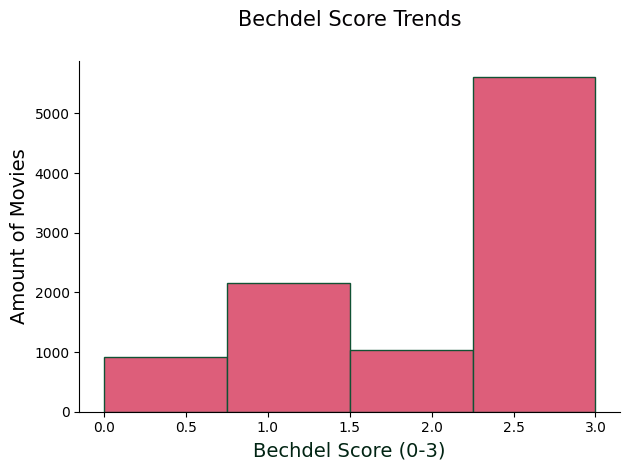

In [63]:
bech_df['bechdel_rating'].hist(bins=4, color="#DD5E7A", edgecolor="#115234")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('Bechdel Score (0-3)', fontsize=14, color= "#012413")
plt.ylabel('Amount of Movies', fontsize=14)
plt.title("Bechdel Score Trends", color= "#030103", pad=25, fontsize=15)

plt.tight_layout()
plt.savefig('../Visualizations/bechrating_hist.png')
plt.show()

Because we are given little information on how the movies included in this dataframe were chosen, a majority of them passing the bechdel test isn't really conclusive of any meaningful insight.  

But this dataframe can be used in comparison with movie titles from other dataframes, specifically titles seen in plots above repeatedly.  

In [64]:
score_0 = bech_df.loc[bech_df['bechdel_rating'] == 0]
score_1 = bech_df.loc[bech_df['bechdel_rating'] == 1]
score_2 = bech_df.loc[bech_df['bechdel_rating'] == 2]
score_3 = bech_df.loc[bech_df['bechdel_rating'] == 3]

def bech_test_score(title):
    if title in bech_df['title'].values:
        if title in score_0['title'].values:
            print(f"{title}'s score: 0")
        if title in score_1['title'].values:
            print(f"{title}'s score: 1")
        if title in score_2['title'].values:
            print(f"{title}'s score: 2")
        if title in score_3['title'].values:
            print(f"{title}'s score: 3")
        else:
            print("Error")
    else:
        print(f"{title}: not found in dataframe")

# use our function to check bechdel test score of top highest revenue 10 horror movies 
bech_test_score("It")
bech_test_score("World War Z")
bech_test_score("The Meg")
bech_test_score("It Chapter Two")
bech_test_score("Jaws")
bech_test_score("The Exorcist")
bech_test_score("The Mummy")
bech_test_score("Halloween")
bech_test_score("The Nun")
bech_test_score("A Quiet Place")


It's score: 3
World War Z's score: 3
The Meg: not found in dataframe
It Chapter Two: not found in dataframe
Jaws's score: 3
The Exorcist: not found in dataframe
The Mummy: not found in dataframe
Halloween's score: 3
The Nun: not found in dataframe
A Quiet Place's score: 3



Five of the movies from the Top 10 highest revenue Horror movies(horror_df) are not found in the bech_df.
But of the remaining 5 that were in both datasets, they all scored a 3 on the bechdel test scale. 
This is not definitive(based on how the data was gathered and where it is from), but does point in the direction... passing the bechdel test is important to movie consumers.  


In [65]:
horrorbech_query = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE movies.movie_genres LIKE "%Horror%" AND ratings.bechdel_rating >= 0
ORDER BY movies.release_date DESC;
"""
pd.read_sql(horrorbech_query, connection)

,title,movie_id,overview
0,Get Out,9192,Chris and his girlfriend Rose go upstate to vi...
1,Black Swan,3050,A journey through the psyche of a young baller...
2,Avatar,2119,Michiko lost her dad in a car accident when sh...
3,Milk,14590,"On a late night, a young teen goes into the ki..."
4,Babe,2199,"A woman is concerned about her boyfriend, who ..."
...,...,...,...
1035,Zombieland,29288,Columbus has made a habit of running from what...
1036,Zombieland: Double Tap,29289,"Columbus, Tallahassee, Wichita, and Little Roc..."
1037,Zoombies,29341,When a strange virus quickly spreads through a...
1038,Zoombies 2,29342,A game ranger arresting poachers ends up savin...


In [66]:
horrorbech3_query = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE movies.movie_genres LIKE "%Horror%" AND ratings.bechdel_rating =3
ORDER BY movies.release_date DESC;
"""
pd.read_sql(horrorbech3_query, connection)

,title,movie_id,overview
0,Get Out,9192,Chris and his girlfriend Rose go upstate to vi...
1,Black Swan,3050,A journey through the psyche of a young baller...
2,Avatar,2119,Michiko lost her dad in a car accident when sh...
3,Babe,2199,"A woman is concerned about her boyfriend, who ..."
4,Beauty and the Beast,2554,"Julie, the youngest daughter of a bankrupt mer..."
...,...,...,...
674,Zombie Strippers!,29253,In the not too distant future a secret governm...
675,Zombieland,29288,Columbus has made a habit of running from what...
676,Zombieland: Double Tap,29289,"Columbus, Tallahassee, Wichita, and Little Roc..."
677,Zoombies,29341,When a strange virus quickly spreads through a...


From the perfect_movie database(combination of all 4 datasets), 1040 movies have horror as a genre or subgenre and have a bechdel rating.   

Of those 1040, 679 score a 3 on the bechdel scale. This isn't enough to definitively say that horror movies tend to lean toward scoring high on the bechdel scale, but it does point to higher rated movies (Oscar winners and nominees, top rated IMDB films) leaning toward higher scores on the bechdel scale.

### So what is needed to make The Perfect Horror Movie?
Looking at characteristics of top rated movies can show us what we need to create the perfect horror movie...  
Using cin_df columns:
- originality  
- impactful  
- immersive  
  
__Explanation of how each column's values are determined:__
      
Originality scale --- "How fresh and unconventional the film's concept and execution feel. 1 = highly derivative, 5 = highly original."

Impactful scale --- "How memorable and resonant the film is afterward. 1 = instantly forgettable, 5 = leaves a massive lasting impact"

Immersive scale --- "How absorbing the viewing experience is. 1 = disconnecting, 5 = hypnotic / fully immersive environment"


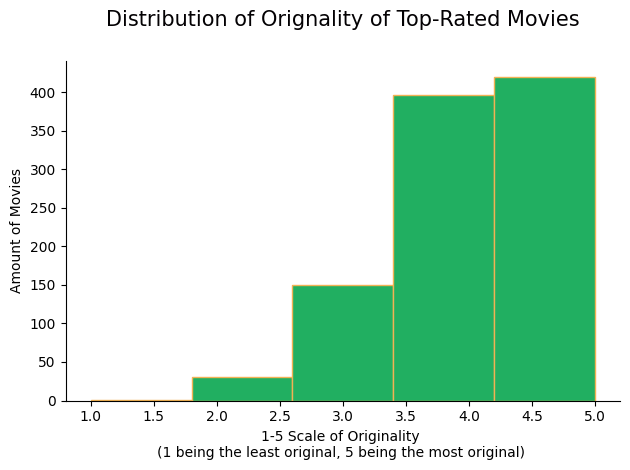

In [67]:
cin_df['originality'].hist(bins=5, color="#21AF61", edgecolor="#F1B254")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('1-5 Scale of Originality \n(1 being the least original, 5 being the most original) ')
plt.ylabel('Amount of Movies')
plt.title("Distribution of Orignality of Top-Rated Movies", color= "#030103", pad=25, fontsize=15)


plt.tight_layout()
plt.savefig('../Visualizations/originality_hist.png')
plt.show()

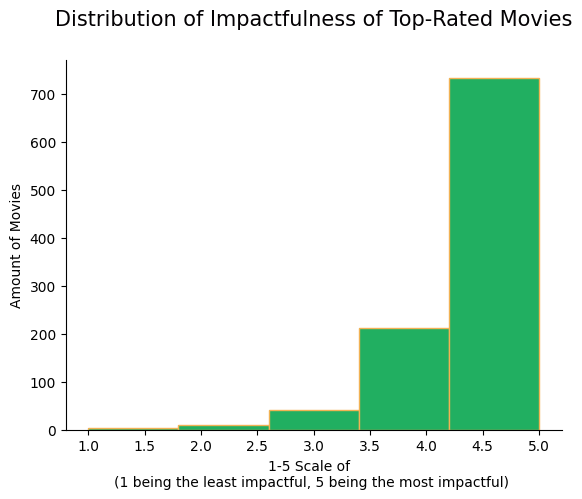

In [68]:
cin_df['impactful'].hist(bins=5, color="#21AF61", edgecolor="#F1B254")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('1-5 Scale of  \n(1 being the least impactful, 5 being the most impactful) ')
plt.ylabel('Amount of Movies')
plt.title("Distribution of Impactfulness of Top-Rated Movies", color= "#030103", pad=25, fontsize=15)

plt.savefig('../Visualizations/impactful_hist.png')
plt.show()

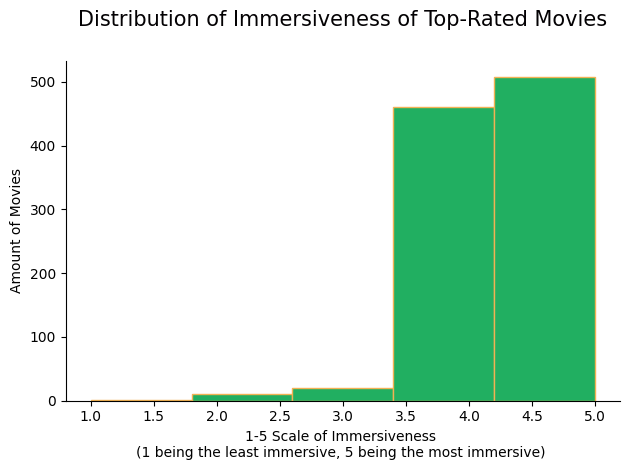

In [69]:
cin_df['immersive'].hist(bins=5, color="#21AF61", edgecolor="#F1B254")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('1-5 Scale of Immersiveness \n(1 being the least immersive, 5 being the most immersive) ')
plt.ylabel('Amount of Movies')
plt.title("Distribution of Immersiveness of Top-Rated Movies", color= "#030103", pad=25, fontsize=15)

plt.tight_layout()
plt.savefig('../Visualizations/immersive_hist.png')
plt.show()

These three plots show that top rated movies score higher on these scales, significantly on the impactful scale. 


How do horror movies score in these categories?  

In [70]:
imp_query = """ 
SELECT DISTINCT movies.title, movies.overview
FROM movies
JOIN cinatomy on cinatomy.movie_id = movies.movie_id
WHERE cinatomy.impactful >= 0 AND movies.movie_genres LIKE "%Horror%";
"""

# used cinatomy.impactful >= 0 to determine if the movies are in the table
pd.read_sql(imp_query, connection)

,title,overview
0,After Hours,Working late is about to get a lot more stress...
1,Alien,"During its return to the earth, commercial spa..."
2,Avatar,Michiko lost her dad in a car accident when sh...
3,Awakenings,"Chased by a malevolent entity, a babysitter's ..."
4,Baby,A young drug addict who has lost touch with he...
...,...,...
63,Victoria,A Victorian man composes a letter to the woman...
64,Wait Until Dark,"After a flight back home, Sam Hendrix returns ..."
65,What Ever Happened to Baby Jane?,A former child star torments her paraplegic si...
66,What We Do in the Shadows,Vampire housemates try to cope with the comple...


The query above pulls a list of movies with horror as a genre (or subgenre) and in the cinatomy table (999 top rated movies).  

In [71]:

imp2_query = """ 
SELECT title, overview
FROM (
    SELECT DISTINCT movies.title, movies.overview, movies.movie_id
    FROM movies
    JOIN cinatomy on cinatomy.movie_id = movies.movie_id
    WHERE cinatomy.impactful >= 0 AND movies.movie_genres LIKE "%Horror%"
) AS filtered_movies
JOIN cinatomy on cinatomy.movie_id = filtered_movies.movie_id
WHERE cinatomy.impactful = 5 AND cinatomy.immersive = 5 AND cinatomy.originality = 5;
"""


pd.read_sql(imp2_query, connection)


,title,overview
0,The Silence of the Lambs,"Jodie Foster stars as Clarice Starling, a top ..."
1,Psycho,When larcenous real estate clerk Marion Crane ...
2,The Shining,Jack Torrance accepts a caretaker job at the O...
3,Alien,"During its return to the earth, commercial spa..."
4,Rear Window,A self-isolated man makes a terrifying discove...
5,Tumbbad,"India, 1918. On the outskirts of Tumbbad, a cu..."
6,Heat,"During an extreme heat wave, a shy girl seeks ..."
7,Stalker,When novelist Paula Martin retreats to the sec...
8,Mommy,"Patty McCormack's ""Mommy"" is psychotically obs..."
9,Underground,A group of friends fight for their lives again...


The query above pulls a list of movies that score 5 in the three categories(originality, impactful, immersive) plotted above.  
  
These two queries show of the 999 top rated movies(after cleaning, originally 1000), 68 movies are horror (or have horror as a subgenre), and of those movie 28 score a 5 in all three categories being analyzed. Which is less than half, but still a significant amount. 

Taking the top 10 highest revenue horror movies and running them through a function to check if they are in the cinatomy dataframe.

In [72]:

def in_cinatomy(title):
    if title in cin_df['title'].values:
        matching_row = cin_df[cin_df['title'] == title]
        print(f" '{title}' is found in cinatomy dataframe")
    else:
        print(f" '{title}' NOT found in this DataFrame")


in_cinatomy("It")
in_cinatomy("World War Z")
in_cinatomy("The Meg")
in_cinatomy("It Chapter Two")
in_cinatomy("Jaws")
in_cinatomy("The Exorcist")
in_cinatomy("The Mummy")
in_cinatomy("Halloween")
in_cinatomy("The Nun")
in_cinatomy("A Quiet Place")


 'It' NOT found in this DataFrame
 'World War Z' NOT found in this DataFrame
 'The Meg' NOT found in this DataFrame
 'It Chapter Two' NOT found in this DataFrame
 'Jaws' is found in cinatomy dataframe
 'The Exorcist' is found in cinatomy dataframe
 'The Mummy' NOT found in this DataFrame
 'Halloween' is found in cinatomy dataframe
 'The Nun' NOT found in this DataFrame
 'A Quiet Place' NOT found in this DataFrame


 
"The 1,000 films skew acclaimed (IMDb top-rated), so scores lean positive overall. This dataset is better suited for relative comparisons than for separating good films from bad ones." - Cinatomy Dataset  

Three movies from the top 10 highest revenue horror movies are found in cin_df.

In [73]:
# creating a new dataframe of the horror movies that are the cinatomy dataframe and also in the top ten highest revenue horror movies list

jaws_occurence = cin_df.loc[cin_df['title'] == "Jaws"]
te_occurence = cin_df.loc[cin_df['title'] == "The Exorcist"]
hw_occurence = cin_df.loc[cin_df['title'] == "Halloween"]

toprev_incin = pd.concat([jaws_occurence, te_occurence, hw_occurence], axis=0)


cintitle = toprev_incin['title']
toprev_incin

,title,pacing_efficiency,originality,family_friendly,plot_quality_rating,plot_quality_reasons_for_liking,plot_quality_reasons_for_disliking,dialogues,end_feeling_emotional_adjective,end_feeling_ending_rating,...,sound_bgm_quality,sound_song_tracks_quality,performance_of_actors,connected,references_contained,cognitive_requirement,technical_knowledge_required,photosensitivity_warnings,animal_harm,trailer_or_spoiler
415,Jaws,4,5,2,5,"['strong_pacing', 'tight_structure']",[],5,energized,5,...,5,1,5,4,1,2,1,1,5,1
419,The Exorcist,3,5,1,5,"['unpredictable', 'strong_pacing', 'tight_stru...",[],4,bittersweet,5,...,5,4,5,1,2,3,1,3,1,5
844,Halloween,3,4,1,4,"['unpredictable', 'strong_pacing', 'tight_stru...",[],3,energized,5,...,5,3,4,1,1,1,1,2,1,3


Below, using the original three cinatomy dataframe categories plotted previously, compare how the new dataframe ranks. 

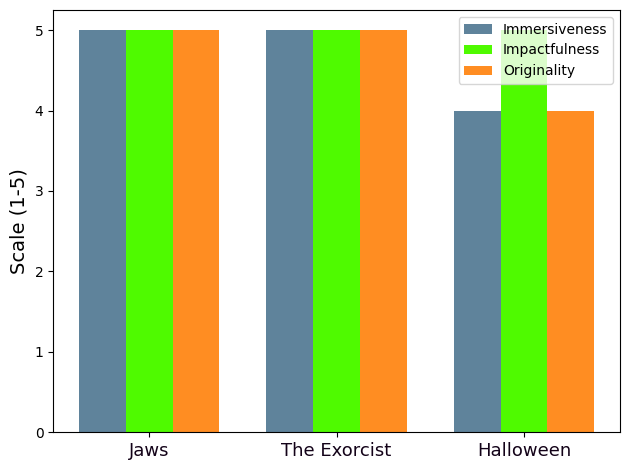

In [74]:
#bars/height
imm_3 = toprev_incin['immersive']
imp_3 = toprev_incin['impactful']
orig_3 = toprev_incin['originality']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, imm_3, width=bar_width, label='Immersiveness', color="#5F839B")
ax.bar(x, imp_3, width=bar_width, label='Impactfulness', color="#4ffa00")
ax.bar(x + bar_width, orig_3, width=bar_width, label='Originality', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title('')
ax.legend()

plt.tight_layout()

plt.savefig('../Visualizations/immimporig_3hor.png')
plt.show()

All three movies listed above have "strong pacing" and "tight structure" as "plot quality reasons for liking".   

Pacing effficiency scale --- "How efficiently the film moves. 1 = dragged, 3 = deliberate / slow-burn, 5 = perfectly fast / thrilling pacing."
  
But none have a 5 score, they fall around deliberate/slowburn to (Jaws leaning towards)thrilling pace.


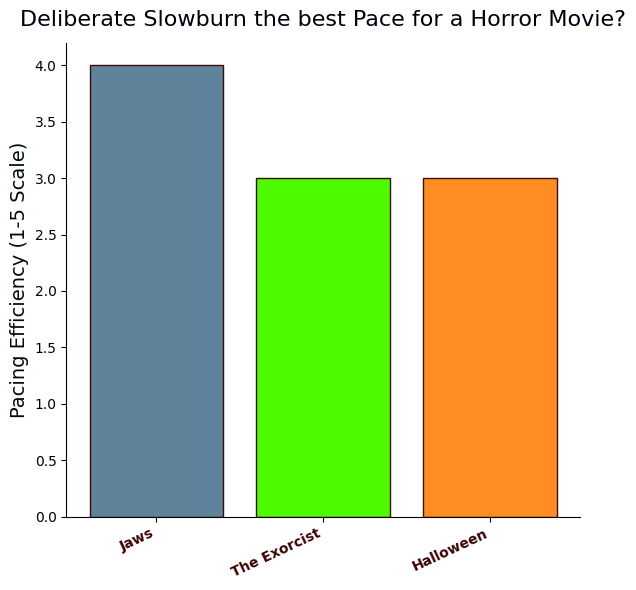

In [75]:
pacing_3 = toprev_incin['pacing_efficiency']

colors = ["#5F839B", "#4ffa00", "#ff8d22"]

plt.figure(figsize=(6,6))
plt.bar(cintitle, pacing_3, color= colors, edgecolor= "#3d0e02")
ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Deliberate Slowburn the best Pace for a Horror Movie?",
          fontsize= 16,
          color= "#01000C",
          pad= 12,
          loc="center")

plt.ylabel("Pacing Efficiency (1-5 Scale)", color= "#010E03", fontsize=14)
plt.xticks(rotation=25, ha="right", color= "#3b0303", fontweight= "bold")



plt.tight_layout()
plt.savefig('../Visualizations/pacing_3hor.png')
plt.show()

All three of these movies are considered Classics to any fan of Horror. Pacing, impact, originality, immersiveness are important factors; but not quite enough to answer the question "what makes the perfect horror movie?". 
  

Looking deeper into what makes these three movies great:
  
Dialogues scale --- "Quality of dialogue writing. 1 = stilted / exposition-heavy, 5 = sharp and authentic."    
Perforamnce of actors scale --- "Quality of the cast's acting performances."  
Plot quality rating scale --- Overall quality of the plot and story construction.

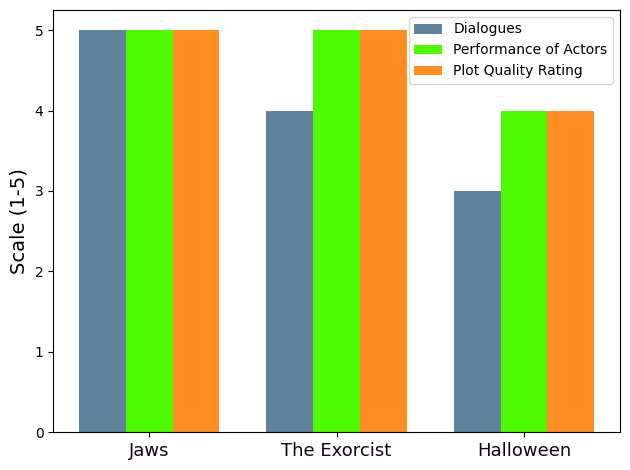

In [76]:
#bars/height
dia_3 = toprev_incin['dialogues']
perf_3 = toprev_incin['performance_of_actors']
plot_3 = toprev_incin['plot_quality_rating']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, dia_3, width=bar_width, label='Dialogues', color="#5F839B")
ax.bar(x, perf_3, width=bar_width, label='Performance of Actors', color="#4ffa00")
ax.bar(x + bar_width, plot_3, width=bar_width, label='Plot Quality Rating', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title('')
ax.legend()

plt.tight_layout()

plt.savefig('../Visualizations/dia_perf_3hor.png')
plt.show()

#### Oscars Dataframe
"This data contains the Oscar Best Picture winners and nominees."

In [77]:
osc_df['movie_genres'].value_counts().sort_values(ascending=False).head(20)

movie_genres
Drama, Classics, Romance                               22
Comedy, Drama, Romance                                 19
Drama                                                  18
Comedy, Drama, Classics, Romance                       16
Drama, Romance                                         15
Drama, History, Biography                               9
Comedy, Drama                                           9
Drama, Classics                                         9
Drama, Biography                                        8
Drama, Classics, History, Biography                     7
Drama, Classics, War, Romance                           5
Comedy, Drama, Biography                                5
Mystery, Mystery & Suspense, Drama, Crime               4
Drama, Art House & International                        4
Classics, Crime, Drama, Mystery, Mystery & Suspense     4
Drama, Crime, Biography                                 4
Comedy, Classics, Romance                               4
C

The top 10 movie_genres categories that have been nominated or won Best Picture at the Oscars shows us an trend towards Dramas, with Romance following close: 

Drama, as movie genre, is focused on emotions and defined by a conflict often set in reality. Typically paired with another genre or subgenre that indicates the film's setting, subject matter, or tone. 

Realism in horror is on the rise as more movies are being made at faster rates with wider reaches(with technological growth). Perhaps, we will see a rise in horror at the Oscar's as the genre grows and more films are made. 
Examples of Realism in Horror:  
- Cape Fear(1962, and the 1991 remake, and 2026 miniseries remake)
- The Last House on the Left (1972, and the 2009 remake)
- The Hitcher (1986)
- Misery (1990)
- The Strangers (2008)
- Green Room (2015)

Checking horror movies that have been nominated for the Oscar Best Picture. 

In [78]:
nom_query = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview, ratings.osc_nomination, ratings.oscar_year
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE movies.movie_genres LIKE "%Horror%" AND ratings.osc_nomination >= 1
ORDER BY movies.release_date DESC;
"""
pd.read_sql(nom_query, connection)

,title,movie_id,overview,osc_nomination,oscar_year
0,Get Out,9192,Chris and his girlfriend Rose go upstate to vi...,1.0,2017
1,The Revenant,25360,A horror movie/buddy comedy about Joey and his...,1.0,2015
2,Black Swan,3050,A journey through the psyche of a young baller...,1.0,2010
3,Avatar,2119,Michiko lost her dad in a car accident when sh...,1.0,2009
4,Milk,14590,"On a late night, a young teen goes into the ki...",1.0,2008
5,Shine,19570,A barbershop quartet sings for their lives in ...,1.0,1996
6,Babe,2199,"A woman is concerned about her boyfriend, who ...",1.0,1995
7,Beauty and the Beast,2554,"Julie, the youngest daughter of a bankrupt mer...",1.0,1991
8,Awakenings,2142,"Chased by a malevolent entity, a babysitter's ...",1.0,1990
9,Ghost,9207,"The story of the film follows Karan Khanna, a ...",1.0,1990


Checking horror movies that have won Oscar Best Picture.

In [79]:
win_query = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview, ratings.osc_win, ratings.oscar_year
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE movies.movie_genres LIKE "%Horror%" AND ratings.osc_win >= 1
ORDER BY ratings.oscar_year;
"""
pd.read_sql(win_query, connection)

,title,movie_id,overview,osc_win,oscar_year
0,Hamlet,10003,A young Prince is visited by the Ghost of his ...,1.0,1948
1,The Apartment,21726,the misadventures of a man in his apartment.,1.0,1960
2,The Silence of the Lambs,25636,"Jodie Foster stars as Clarice Starling, a top ...",1.0,1991
3,The Artist,21748,Peter as an artist is dangerously obsessed wit...,1.0,2011


Jaws and The Exorcist (which we have already taken a more indepth look at) were both nominated for the Oscar Best Picture, with no wins.  

Halloween did score lower than The Exorcist and Jaws overall in the cinatomy categories analyzed, so it is not entirely surprising it did not get nominated or win Best Picture at the Oscars. 

The below queries look at the other movies nominated the same year, and the winner of the Oscar Best Picture that year.


In [80]:
query1975 = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview, ratings.osc_win, ratings.osc_nomination
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE ratings.oscar_year = 1975;
"""
pd.read_sql(query1975, connection)

,title,movie_id,overview,osc_win,osc_nomination
0,Barry Lyndon,2429,How does an Irish lad without prospects become...,0.0,1.0
1,Dog Day Afternoon,6948,When inexperienced criminal Sonny Wortzik (Al ...,0.0,1.0
2,Jaws,12111,When an insatiable great white shark terrorize...,0.0,1.0
3,Nashville,15414,"In this acclaimed Robert Altman drama, the liv...",0.0,1.0
4,One Flew Over the Cuckoo's Nest,16330,When Randle Patrick McMurphy (Jack Nicholson) ...,1.0,0.0


In [81]:
query1973 = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview, ratings.osc_win, ratings.osc_nomination
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE ratings.oscar_year = 1973;
"""
pd.read_sql(query1973, connection)

,title,movie_id,overview,osc_win,osc_nomination
0,A Touch of Class,792,An affair between a married American insurance...,0.0,1.0
1,American Graffiti,1404,"On the last day of summer vacation in 1962, fr...",0.0,1.0
2,Cries and Whispers,5176,As Agnes (Harriet Andersson) slowly dies of ca...,0.0,1.0
3,The Exorcist,23101,12-year-old Regan MacNeil begins to adapt an e...,0.0,1.0
4,The Sting,25811,"Following the murder of a mutual friend, aspir...",1.0,0.0


Using in_cinatomy function to check if the Oscar Best Pictures the Year The Exorcist and the year Jaws were nominated are in the cinatomy dataframe.


In [82]:
in_cinatomy("One Flew Over the Cuckoo's Nest")
in_cinatomy("The Sting")

 'One Flew Over the Cuckoo's Nest' is found in cinatomy dataframe
 'The Sting' is found in cinatomy dataframe


Setting up two new dataframes to visually compare the winners to the horror movies nominated the same year.

In [83]:
# 1973
te_occurence = cin_df.loc[cin_df['title'] == "The Exorcist"]
ts_occurence = cin_df.loc[cin_df['title'] == "The Sting"]
te_vs_ts = pd.concat([te_occurence, ts_occurence], axis=0)


# 1975
jaws_occurence = cin_df.loc[cin_df['title'] == "Jaws"]
ofo_occurence = cin_df.loc[cin_df['title'] == "One Flew Over the Cuckoo's Nest"]
jaws_vs_ofo = pd.concat([jaws_occurence, ofo_occurence], axis=0)



Comparing the original categories we looked at in depth of the new dataframes. 

#### The Exorcist compared to The Sting: 

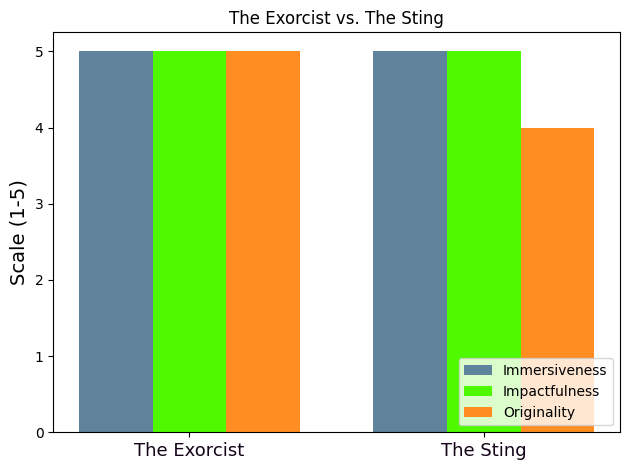

In [84]:
cintitle = te_vs_ts['title']


#bars/height
imm_1973 = te_vs_ts['immersive']
imp_1973 = te_vs_ts['impactful']
orig_1973 = te_vs_ts['originality']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, imm_1973, width=bar_width, label='Immersiveness', color="#5F839B")
ax.bar(x, imp_1973, width=bar_width, label='Impactfulness', color="#4ffa00")
ax.bar(x + bar_width, orig_1973, width=bar_width, label='Originality', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("The Exorcist vs. The Sting")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/te_vs_tsIMIMOR.png')
plt.show()

Comparitively, the scoring of The Exorcist and The Sting are very similar.

Take a deeper look into other categories:  
  
End feeling end rating ---  "Overall quality rating of the ending itself"  
Overall feeling ---"The model's holistic overall impression/enjoyment rating of the film."  
Plot quality rating --- "Overall quality of the plot and story construction."  

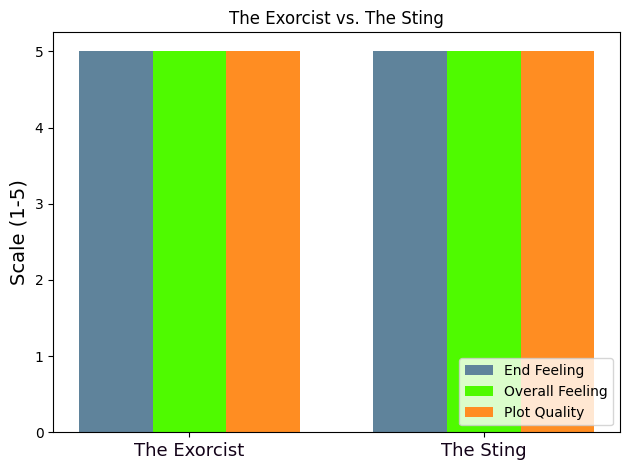

In [85]:

#bars/height
end_1973 = te_vs_ts['end_feeling_ending_rating']
over_1973 = te_vs_ts['overall_feeling']
plot_1973 = te_vs_ts['plot_quality_rating']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, end_1973, width=bar_width, label='End Feeling', color="#5F839B")
ax.bar(x, over_1973, width=bar_width, label='Overall Feeling', color="#4ffa00")
ax.bar(x + bar_width, plot_1973, width=bar_width, label='Plot Quality', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("The Exorcist vs. The Sting")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/te_vs_tsEFOVPQ.png')
plt.show()

No difference in scoring between The Exorcist and The Sting regarding the three new categories checked.  
  
After looking at categories that score feelings/emotions around the films and the plot; I'd like to look at categories scored on quality(of writing, visual composition, and visual effects).

Visuals scale -- "Quality of cinematography and visual composition."  
Visual effects scale -- "Quality and believability of visual/special effects (CGI and practical)."  
Dialogues scale -- "Quality of dialogue writing. 1 = stilted / exposition-heavy, 5 = sharp and authentic."  

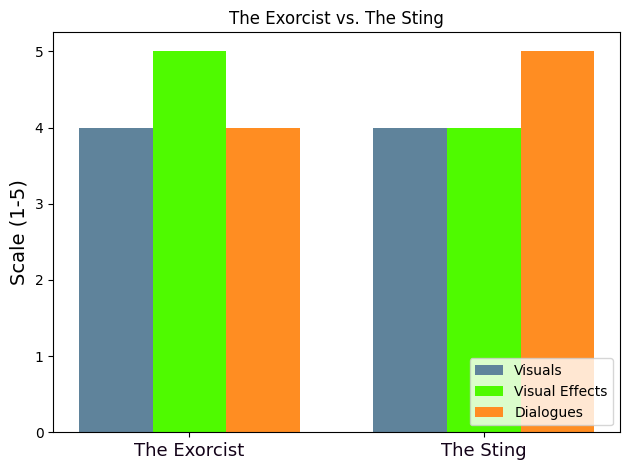

In [86]:
#bars/height
vis_1973 = te_vs_ts['visuals']
visef_1973 = te_vs_ts['visual_effects']
dia_1973 = te_vs_ts['dialogues']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, vis_1973, width=bar_width, label='Visuals', color="#5F839B")
ax.bar(x, visef_1973, width=bar_width, label='Visual Effects', color="#4ffa00")
ax.bar(x + bar_width, dia_1973, width=bar_width, label='Dialogues', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("The Exorcist vs. The Sting")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/te_vs_tsVisDia.png')
plt.show()

The Exorcist scored higher for visual effects than The Sting, but lower in the dialogues category.  
The comparison is still relatively even.

Do consumers want intellectual movies or would they prefer a movie they feel emotionally connected to? Does the performance of the actors effect how connected the consumer feels?  


Performance of actors scale -- "Quality of the cast's acting performances."  
Connected scale -- "How emotionally connected to the characters/story a viewer is likely to feel. 1 = detached, 5 = deeply"  
Cognitive requirment scale-- "Mental effort required to follow and understand the film. 1 = passive / easy to follow, 5 = demands close attention" 

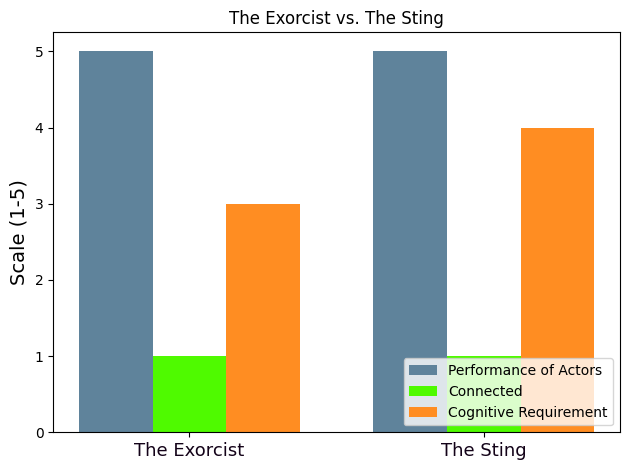

In [87]:
#bars/height
poa_1973 = te_vs_ts['performance_of_actors']
con_1973 = te_vs_ts['connected']
cog_1973 = te_vs_ts['cognitive_requirement']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, poa_1973, width=bar_width, label='Performance of Actors', color="#5F839B")
ax.bar(x, con_1973, width=bar_width, label='Connected', color="#4ffa00")
ax.bar(x + bar_width, cog_1973, width=bar_width, label='Cognitive Requirement', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("The Exorcist vs. The Sting")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/te_vs_tsCCPOA.png')
plt.show()

While not definitive, the quality of the performance from the actors seems a significant factor in making a great movie. Both movies scored high in that category.  
However, in the cognitive requirement category it does not appear consumers want a movie that is too easy to follow but they also don't want a movie that demands their complete attention. Like pacing efficiency, it appears it is better to have a middle ground than a score of 5.  
Both movies lack creating a deep connection with with consumer, but this is clearly not an issue for these movies(both being Oscar Best Picture nominated). 
  

From these graphs, these two movies score incredibly similar making it difficult to answer if one is the better movie. As well, as leaving this analysis with no definitive answer to the question.... Does horror really get snubbed at the Oscars.

#### Jaws compared to One Flew Over the Cuckoo's Nest: 
(following the same process as above)


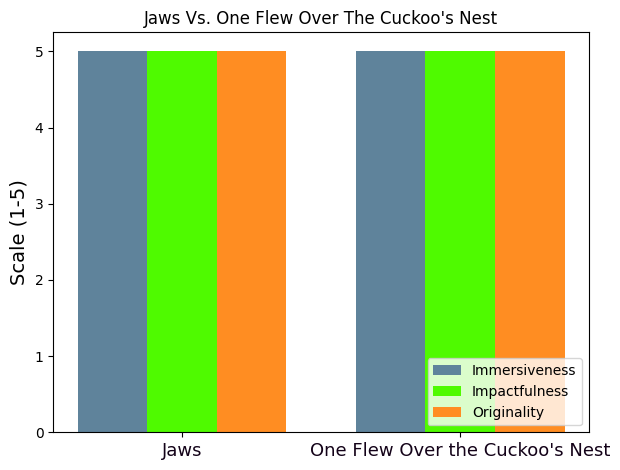

In [88]:
cintitle = jaws_vs_ofo['title']


#bars/height
imm_1975 = jaws_vs_ofo['immersive']
imp_1975 = jaws_vs_ofo['impactful']
orig_1975 = jaws_vs_ofo['originality']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, imm_1975, width=bar_width, label='Immersiveness', color="#5F839B")
ax.bar(x, imp_1975, width=bar_width, label='Impactfulness', color="#4ffa00")
ax.bar(x + bar_width, orig_1975, width=bar_width, label='Originality', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("Jaws Vs. One Flew Over The Cuckoo's Nest")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/jaws_vs_ofoIMIMOR.png')
plt.show()

Jaws and One Flew Over the Cuckoo's Nest score exactly the same in immersiveness, impactfulness, and originality. 

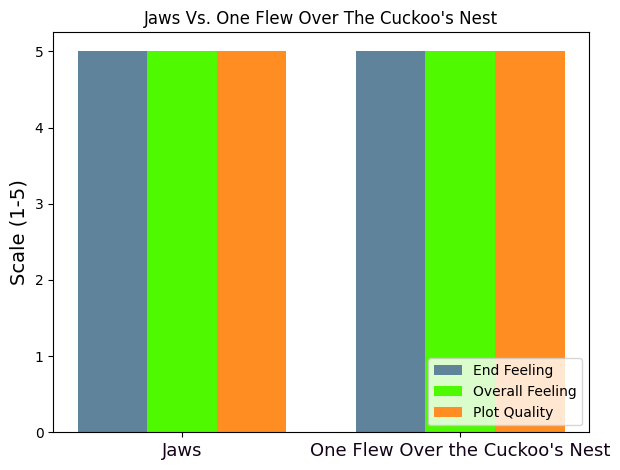

In [89]:

#bars/height
end_1975 = jaws_vs_ofo['end_feeling_ending_rating']
over_1975 = jaws_vs_ofo['overall_feeling']
plot_1975 = jaws_vs_ofo['plot_quality_rating']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, end_1975, width=bar_width, label='End Feeling', color="#5F839B")
ax.bar(x, over_1975, width=bar_width, label='Overall Feeling', color="#4ffa00")
ax.bar(x + bar_width, plot_1975, width=bar_width, label='Plot Quality', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("Jaws Vs. One Flew Over The Cuckoo's Nest")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/jaws_vs_ofoEFOVPQ.png')
plt.show()

They also score the same in end feeling, overall feeling, and plot quality. 

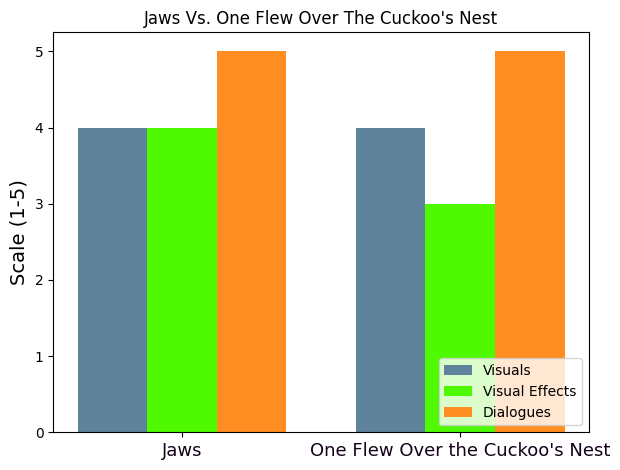

In [90]:
#bars/height
vis_1975 = jaws_vs_ofo['visuals']
visef_1975 = jaws_vs_ofo['visual_effects']
dia_1975 = jaws_vs_ofo['dialogues']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, vis_1975, width=bar_width, label='Visuals', color="#5F839B")
ax.bar(x, visef_1975, width=bar_width, label='Visual Effects', color="#4ffa00")
ax.bar(x + bar_width, dia_1975, width=bar_width, label='Dialogues', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("Jaws Vs. One Flew Over The Cuckoo's Nest")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/jaws_vs_ofoVisDia.png')
plt.show()

Jaws scores better in visual effects than One Flew Over the Cuckoo's Nest, which is not surprising given the practical effects and use of an animatronic shark in Jaws. 
The animatronic shark malfunctioned often enough it influenced creative choices of the film, such as camera techniques and sound design, leading to the iconic tension building that the film is known for.   


[Bruce the Shark]:https://boldentrance.com/remembering-bruce-the-malfunctioning-animatronic-shark-that-made-jaws-a-horror-classic/


More Information about how [Bruce the Shark][Bruce the Shark] effected the making of Jaws and the horror genre as a whole. 

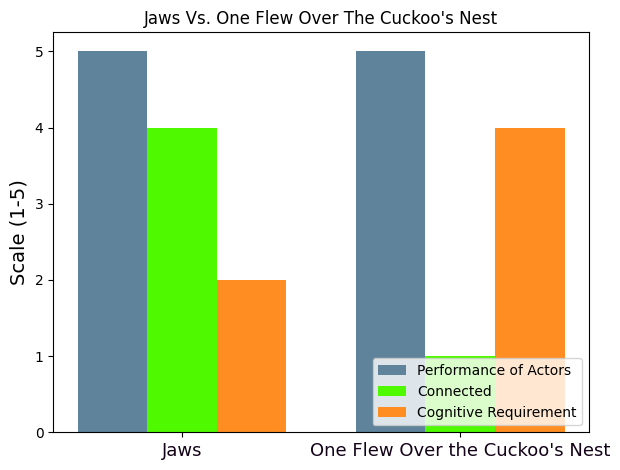

In [91]:
#bars/height
poa_1975 = jaws_vs_ofo['performance_of_actors']
con_1975 = jaws_vs_ofo['connected']
cog_1975 = jaws_vs_ofo['cognitive_requirement']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, poa_1975, width=bar_width, label='Performance of Actors', color="#5F839B")
ax.bar(x, con_1975, width=bar_width, label='Connected', color="#4ffa00")
ax.bar(x + bar_width, cog_1975, width=bar_width, label='Cognitive Requirement', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("Jaws Vs. One Flew Over The Cuckoo's Nest")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/jaws_vs_ofoCCPOA.png')
plt.show()

Both movies cognitive requirement scores fall in the middle, not to any extreme.  Both score high for the quality of the performance of the actors. Jaws score shows the film connects more with the audience than One Flew Over the Cuckoo's Nest.  

##### What do these visuals tell us? 
With scores so close in most categories, it's difficult to determine why one movie beat the other for Oscar Best Picture. It is possible that the Oscar's are snubbing the horror genre; but it's also possible that more information is needed, more comparisons can be made, and a closer look can be taken at how a movie is recieved based on __when__ it is made.


#### The Silence of The Lambs:  
The Silence of the Lambs won Best Picture at the Oscar's in 1991. How does it's cinatomy scores compare to the horror nominees above? 

In [92]:
in_cinatomy("The Silence of the Lambs")

 'The Silence of the Lambs' is found in cinatomy dataframe


In [93]:
occurence = cin_df.loc[cin_df['title'] == "The Silence of the Lambs"]
occurence.drop(columns=['title', 'family_friendly','plot_quality_reasons_for_liking', 'plot_quality_reasons_for_disliking', 'end_feeling_emotional_adjective', 'end_feeling_structural_adjective', 'sound_bgm_quality', 'sound_song_tracks_quality', 'references_contained', 'technical_knowledge_required', 'animal_harm', 'trailer_or_spoiler', 'photosensitivity_warnings', 'sound_audio_balance_issue'], inplace=True)
occurence = occurence.iloc[0]
#columns to use: occurence[['immersive', 'impactful', 'originality', 'pacing_efficiency', 'dialogues', 'performance_of_actors', 'plot_quality_rating', 'visuals', 'visual_effects', 'connected', 'cognitive_requirement']]
occurence


pacing_efficiency            4
originality                  5
plot_quality_rating          5
dialogues                    5
end_feeling_ending_rating    5
immersive                    5
impactful                    5
overall_feeling              5
visuals                      4
visual_effects               3
performance_of_actors        5
connected                    3
cognitive_requirement        4
Name: 28, dtype: int64

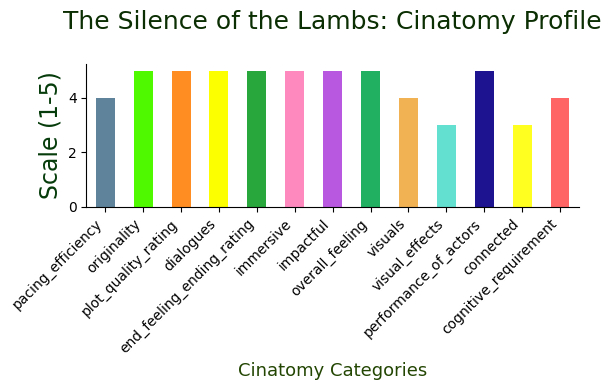

In [94]:
custom_colors = ["#5F839B", "#4ffa00", "#ff8d22", "#FBFF00", "#27A73C", "#FD89BF", "#B857DF", "#21AF61", "#F1B254", "#64E0D0", "#1D128F", "#FFFF20", "#FF6564", "#F88898"]


plt.figure(figsize=(6, 4))
occurence.plot(kind='bar', color= custom_colors)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("The Silence of the Lambs: Cinatomy Profile", fontsize= 18, color= "#0B2E02", pad= 25)


plt.ylabel("Scale (1-5)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Cinatomy Categories", color= "#234603", fontsize=13)




plt.tight_layout()
plt.savefig('../Visualizations/silence_of_the_lambs.png')
plt.show()

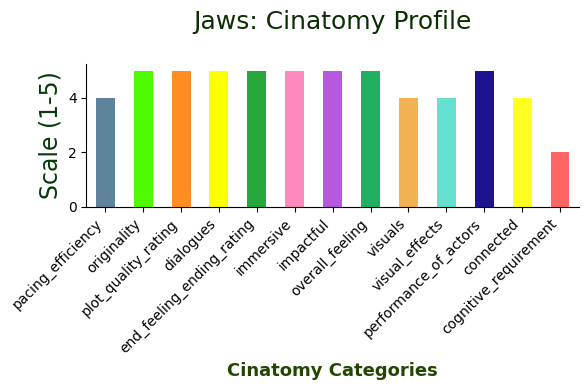

In [95]:
occurence2 = cin_df.loc[cin_df['title'] == "Jaws"]
occurence2.drop(columns=['title', 'family_friendly','plot_quality_reasons_for_liking', 'plot_quality_reasons_for_disliking', 'end_feeling_emotional_adjective', 'end_feeling_structural_adjective', 'sound_bgm_quality', 'sound_song_tracks_quality', 'references_contained', 'technical_knowledge_required', 'animal_harm', 'trailer_or_spoiler', 'photosensitivity_warnings', 'sound_audio_balance_issue'], inplace=True)
occurence2 = occurence2.iloc[0]

custom_colors = ["#5F839B", "#4ffa00", "#ff8d22", "#FBFF00", "#27A73C", "#FD89BF", "#B857DF", "#21AF61", "#F1B254", "#64E0D0", "#1D128F", "#FFFF20", "#FF6564", "#F88898"]


plt.figure(figsize=(6, 4))
occurence2.plot(kind='bar', color= custom_colors)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Jaws: Cinatomy Profile", fontsize= 18, color= "#0B2E02", pad= 25)


plt.ylabel("Scale (1-5)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Cinatomy Categories", color= "#234603", fontsize=13, fontweight="bold")




plt.tight_layout()
plt.savefig('../Visualizations/jaws.png')
plt.show()


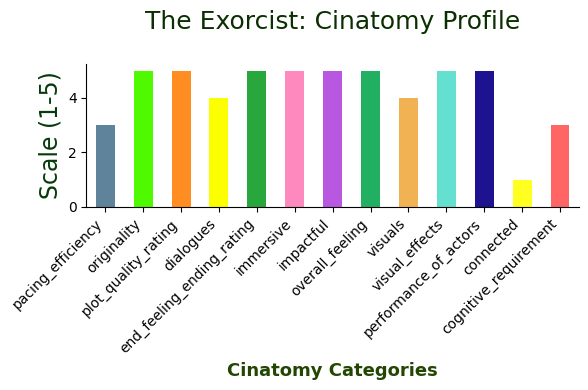

In [96]:
occurence3 = cin_df.loc[cin_df['title'] == "The Exorcist"]
occurence3.drop(columns=['title', 'family_friendly','plot_quality_reasons_for_liking', 'plot_quality_reasons_for_disliking', 'end_feeling_emotional_adjective', 'end_feeling_structural_adjective', 'sound_bgm_quality', 'sound_song_tracks_quality', 'references_contained', 'technical_knowledge_required', 'animal_harm', 'trailer_or_spoiler', 'photosensitivity_warnings', 'sound_audio_balance_issue'], inplace=True)
occurence3 = occurence3.iloc[0]


custom_colors = ["#5F839B", "#4ffa00", "#ff8d22", "#FBFF00", "#27A73C", "#FD89BF", "#B857DF", "#21AF61", "#F1B254", "#64E0D0", "#1D128F", "#FFFF20", "#FF6564", "#F88898"]

plt.figure(figsize=(6, 4))
occurence3.plot(kind='bar', color= custom_colors)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("The Exorcist: Cinatomy Profile", fontsize= 18, color= "#0B2E02", pad= 25)



plt.ylabel("Scale (1-5)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Cinatomy Categories", color= "#234603", fontsize=13, fontweight="bold")




plt.tight_layout()
plt.savefig('../Visualizations/theexorcist.png')
plt.show()

In [97]:
connection.close()
print('Connection closed.')

Connection closed.
